In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import scipy as sp
from scipy import sparse, io
import glob 
import re

Data was downloaded from [the zenodo link](https://zenodo.org/record/3345981#.YB1E3nX7Srf) in the paper (`expression_matrices.tar`). There's count matrices for 4 normal donors but no metadata. There's also seurat objects for the 5 AML patient samples but will work the raw count matrices for these samples too so they're in the same format. Have to assume this data hasn't been QC-ed.

Will start with the healthy donors.

In [7]:
adatas = []
adata = sc.read('../data/petti/ND_083017.matrix.mtx').T
adata.obs_names = pd.read_csv('../data/petti/ND_083017.barcodes.tsv', delimiter='\t', header=None)[0].values
adata.var_names = pd.read_csv('../data/petti/ND_083017.genes.tsv', delimiter='\t', header=None)[1]
adata

AnnData object with n_obs × n_vars = 5860 × 33538

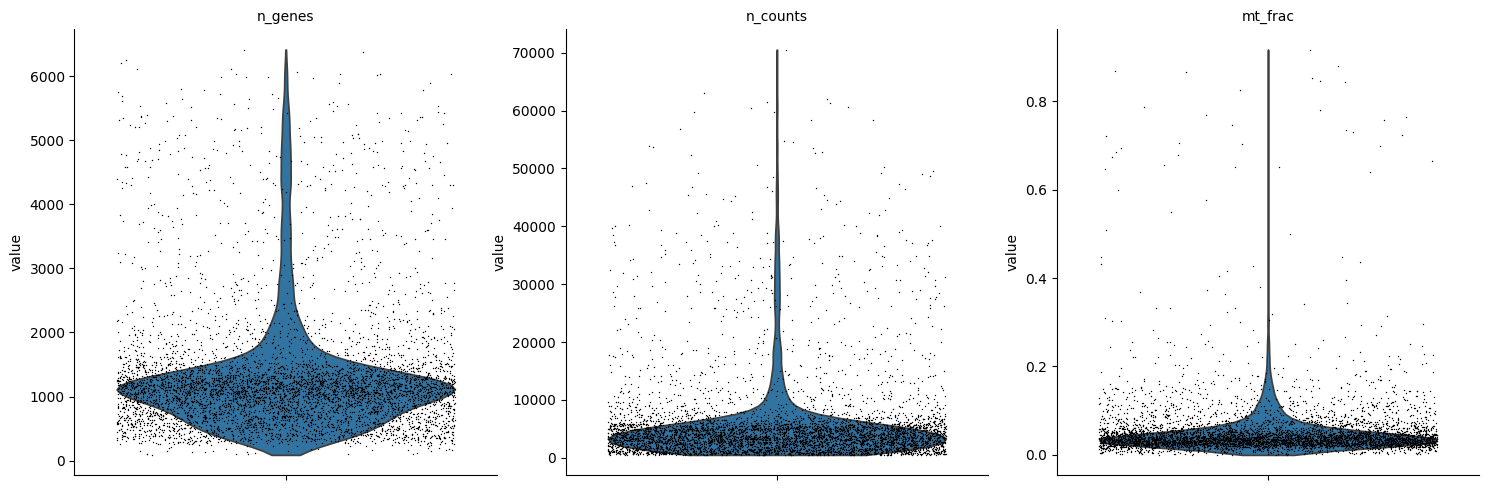

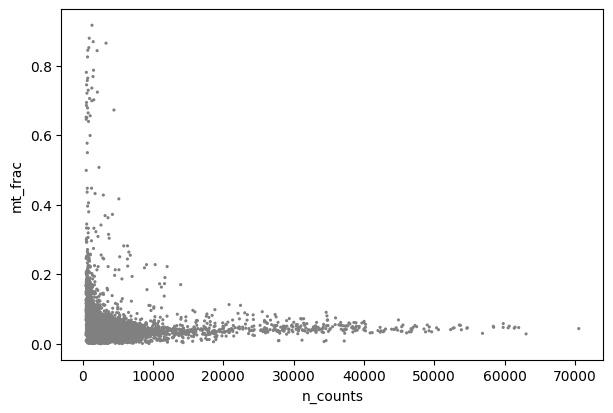

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scanpy\plotting\_utils.py:716: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  color = color[sort]


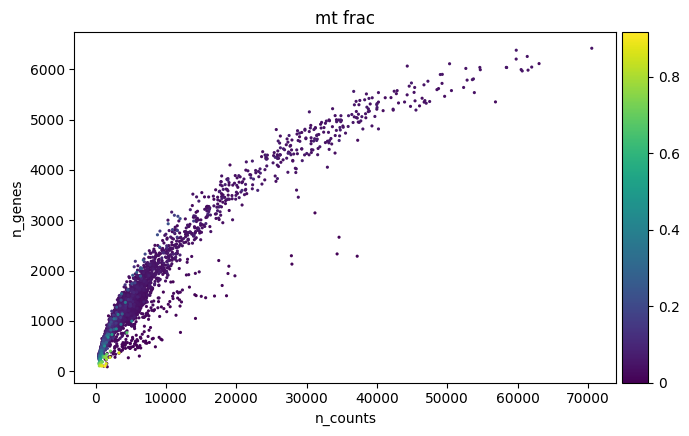

In [8]:
# Quality control - calculate QC covariates
adata.var_names_make_unique()
adata.obs['n_counts'] = adata.X.sum(1)
adata.obs['log_counts'] = np.log(adata.obs['n_counts'])
adata.obs['n_genes'] = (adata.X > 0).sum(1)

adata.X = adata.X.toarray()
mt_gene_mask = [gene.startswith('MT-') for gene in adata.var_names]
adata.obs['mt_frac'] = adata.X[:, mt_gene_mask].sum(1)/adata.obs['n_counts']

# Quality control - plot QC metrics
sc.pl.violin(adata, ['n_genes', 'n_counts', 'mt_frac'],
             jitter=0.4, multi_panel=True)

sc.pl.scatter(adata, x='n_counts', y='mt_frac')
sc.pl.scatter(adata, x='n_counts', y='n_genes', color='mt_frac')

C:\Users\User\AppData\Local\Temp\ipykernel_10228\2253007655.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p3 = sb.distplot(adata.obs['n_counts'], kde=False)


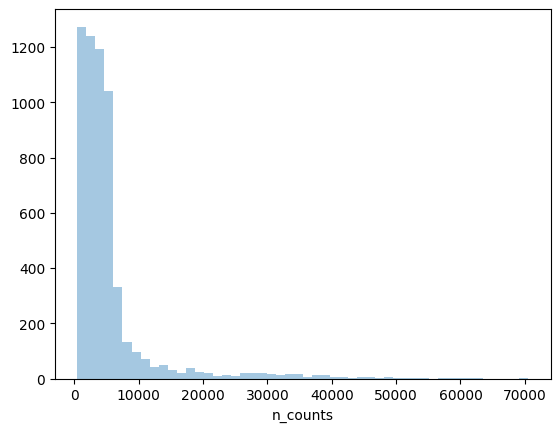

C:\Users\User\AppData\Local\Temp\ipykernel_10228\2253007655.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p4 = sb.distplot(adata.obs['n_counts'][adata.obs['n_counts']<10000], kde=False, bins=60)


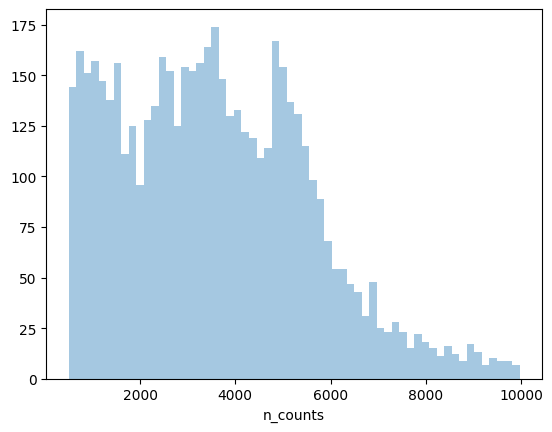

C:\Users\User\AppData\Local\Temp\ipykernel_10228\2253007655.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p5 = sb.distplot(adata.obs['n_counts'][adata.obs['n_counts']>10000], kde=False, bins=60)


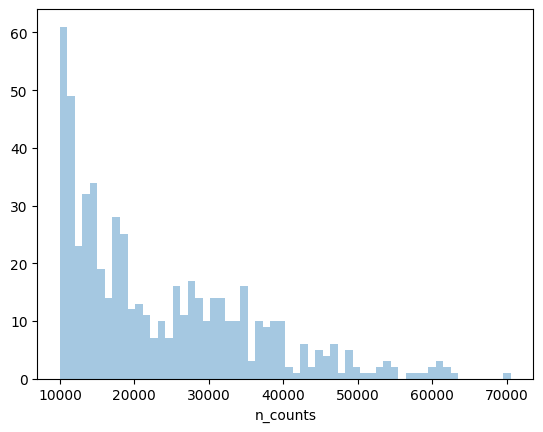

In [9]:
#Thresholding decision: counts
p3 = sb.distplot(adata.obs['n_counts'], kde=False)
plt.show()

p4 = sb.distplot(adata.obs['n_counts'][adata.obs['n_counts']<10000], kde=False, bins=60)
plt.show()

p5 = sb.distplot(adata.obs['n_counts'][adata.obs['n_counts']>10000], kde=False, bins=60)
plt.show()

In [10]:
# Filter cells according to identified QC thresholds:
print('Total number of cells: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, max_counts = 60000)
print('Number of cells after max count filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['mt_frac'] < 0.6]
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Total number of cells: 5860
Number of cells after max count filter: 5853
Number of cells after MT filter: 5822


C:\Users\User\AppData\Local\Temp\ipykernel_10228\710109103.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p6 = sb.distplot(adata.obs['n_genes'], kde=False, bins=60)


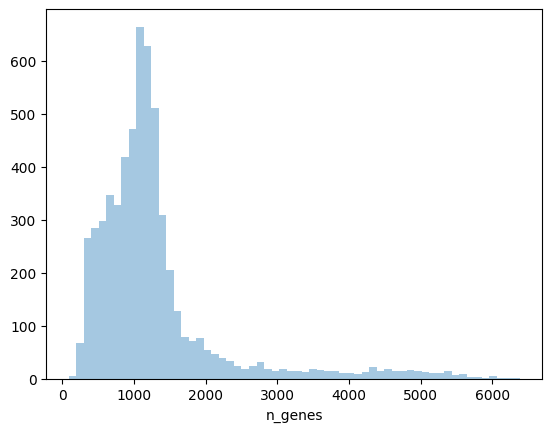

C:\Users\User\AppData\Local\Temp\ipykernel_10228\710109103.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p7 = sb.distplot(adata.obs['n_genes'][adata.obs['n_genes'] < 1000], kde=False, bins=60)


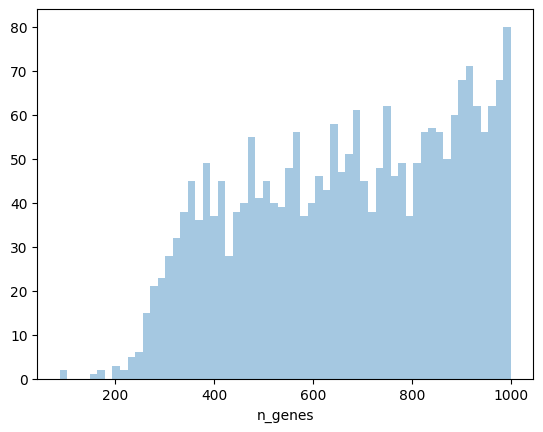

In [11]:
#Thresholding decision: genes
p6 = sb.distplot(adata.obs['n_genes'], kde=False, bins=60)
plt.show()

p7 = sb.distplot(adata.obs['n_genes'][adata.obs['n_genes'] < 1000], kde=False, bins=60)
plt.show()

In [12]:
# Filter cells according to identified QC thresholds:
print('Total number of cells: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes = 400)
print('Number of cells after min genes filter: {:d}'.format(adata.n_obs))

Total number of cells: 5822


C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scanpy\preprocessing\_simple.py:139: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['n_genes'] = number


Number of cells after min genes filter: 5497


C:\Users\User\AppData\Local\Temp\ipykernel_10228\1808565410.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(adata.obs['mt_frac'][adata.obs['mt_frac'] < 0.05], kde=False, bins=60)


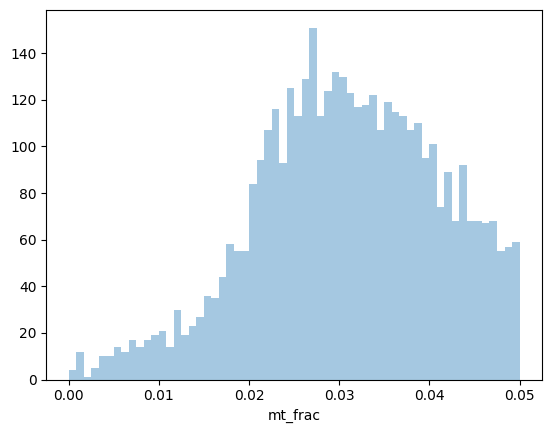

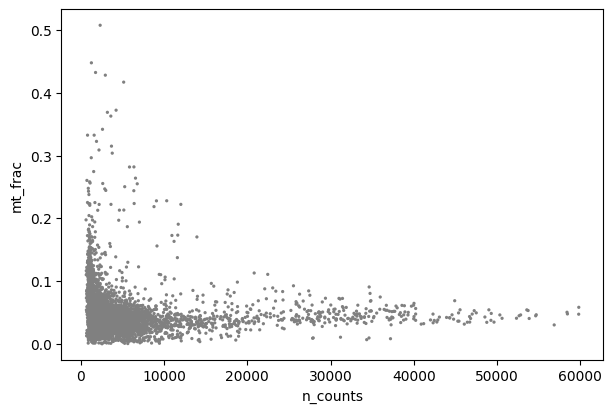

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scanpy\plotting\_utils.py:716: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  color = color[sort]


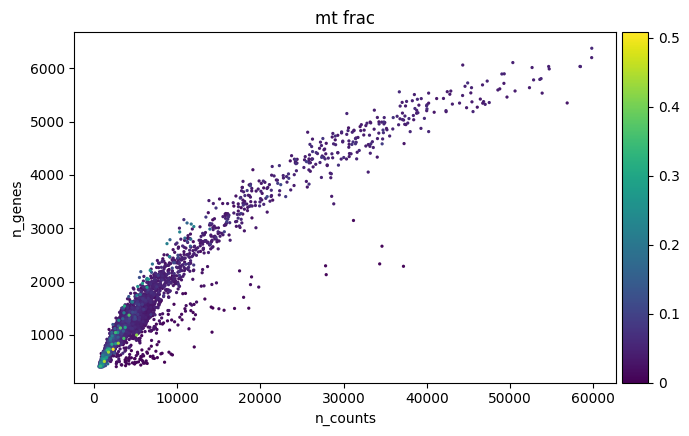

In [13]:
sb.distplot(adata.obs['mt_frac'][adata.obs['mt_frac'] < 0.05], kde=False, bins=60)
plt.show()
sc.pl.scatter(adata, x='n_counts', y='mt_frac')
sc.pl.scatter(adata, x='n_counts', y='n_genes', color='mt_frac')

In [14]:
# Thresholding on number of counts and percent_mito
print('Total number of cells: {:d}'.format(adata.n_obs))
adata = adata[(adata.obs['mt_frac'] > 0.01) | (adata.obs['n_counts'] > 7500)]

print('Number of cells after filter: {:d}'.format(adata.n_obs))

Total number of cells: 5497
Number of cells after filter: 5395


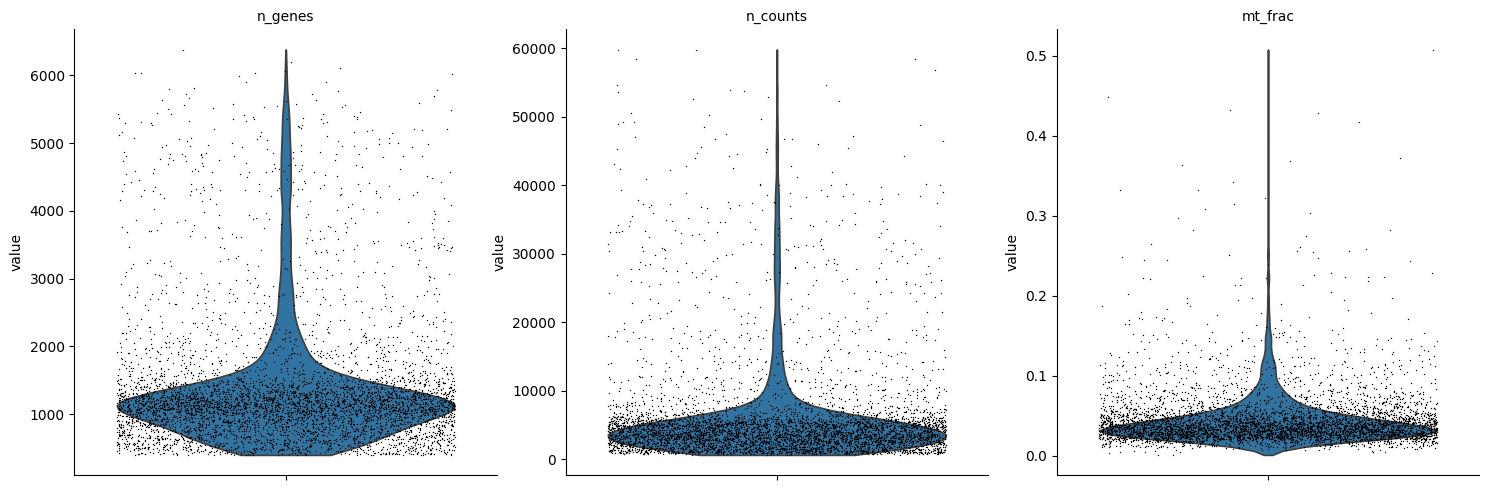

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scanpy\plotting\_utils.py:716: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  color = color[sort]


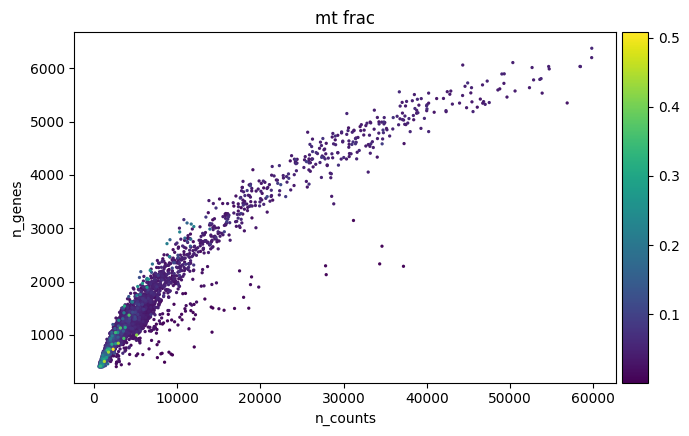

In [15]:
# visualise QC metrics after filtering
sc.pl.violin(adata, ['n_genes', 'n_counts', 'mt_frac'], jitter=0.4, multi_panel=True)
sc.pl.scatter(adata, x='n_counts', y='n_genes', color='mt_frac')

In [16]:
adata.obs['sample'] = 'ND_083017'
adata.obs['timepoint'] = 'Healthy'
adatas.append(adata)

C:\Users\User\AppData\Local\Temp\ipykernel_10228\3443836717.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['sample'] = 'ND_083017'


In [17]:
adata = sc.read('../data/petti/ND_090617.matrix.mtx').T
adata.obs_names = pd.read_csv('../data/petti/ND_090617.barcodes.tsv', delimiter='\t', header=None)[0].values
adata.var_names = pd.read_csv('../data/petti/ND_090617.genes.tsv', delimiter='\t', header=None)[1]
adata

AnnData object with n_obs × n_vars = 7197 × 33538

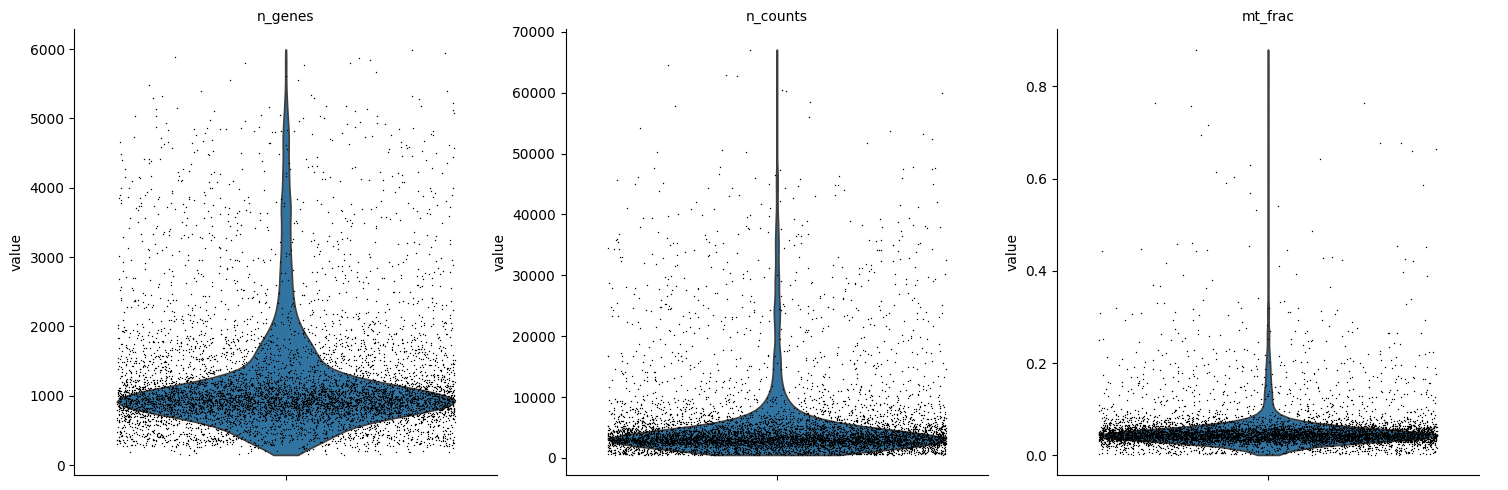

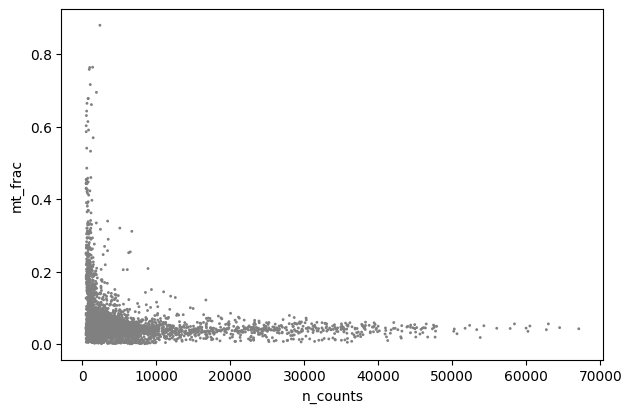

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scanpy\plotting\_utils.py:716: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  color = color[sort]


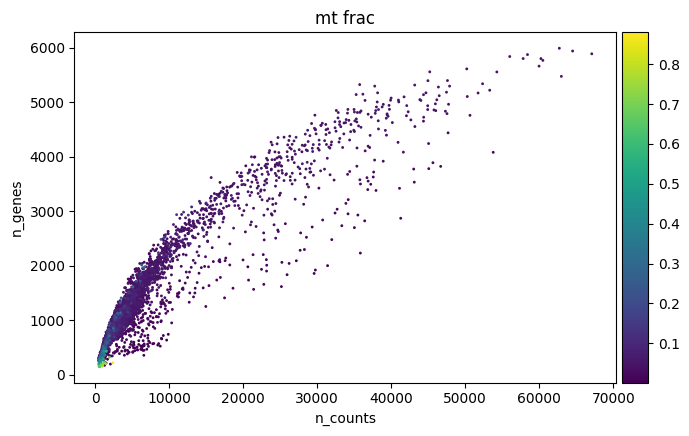

In [18]:
# Quality control - calculate QC covariates
adata.var_names_make_unique()
adata.obs['n_counts'] = adata.X.sum(1)
adata.obs['log_counts'] = np.log(adata.obs['n_counts'])
adata.obs['n_genes'] = (adata.X > 0).sum(1)

adata.X = adata.X.toarray()
mt_gene_mask = [gene.startswith('MT-') for gene in adata.var_names]
adata.obs['mt_frac'] = adata.X[:, mt_gene_mask].sum(1)/adata.obs['n_counts']

# Quality control - plot QC metrics
sc.pl.violin(adata, ['n_genes', 'n_counts', 'mt_frac'],
             jitter=0.4, multi_panel=True)

sc.pl.scatter(adata, x='n_counts', y='mt_frac')
sc.pl.scatter(adata, x='n_counts', y='n_genes', color='mt_frac')

C:\Users\User\AppData\Local\Temp\ipykernel_10228\2253007655.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p3 = sb.distplot(adata.obs['n_counts'], kde=False)


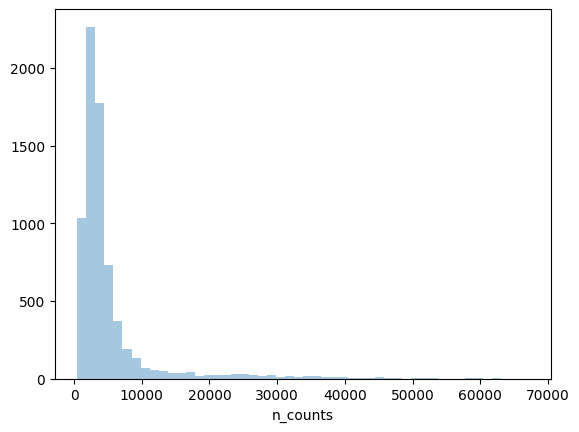

C:\Users\User\AppData\Local\Temp\ipykernel_10228\2253007655.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p4 = sb.distplot(adata.obs['n_counts'][adata.obs['n_counts']<10000], kde=False, bins=60)


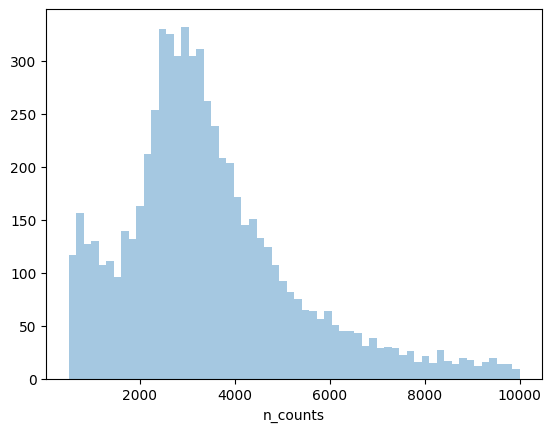

C:\Users\User\AppData\Local\Temp\ipykernel_10228\2253007655.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p5 = sb.distplot(adata.obs['n_counts'][adata.obs['n_counts']>10000], kde=False, bins=60)


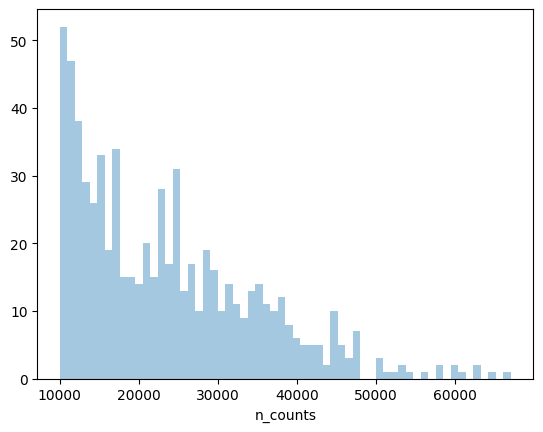

In [19]:
#Thresholding decision: counts
p3 = sb.distplot(adata.obs['n_counts'], kde=False)
plt.show()

p4 = sb.distplot(adata.obs['n_counts'][adata.obs['n_counts']<10000], kde=False, bins=60)
plt.show()

p5 = sb.distplot(adata.obs['n_counts'][adata.obs['n_counts']>10000], kde=False, bins=60)
plt.show()

In [20]:
# Filter cells according to identified QC thresholds:
print('Total number of cells: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, max_counts = 60000)
print('Number of cells after max count filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['mt_frac'] < 0.5]
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Total number of cells: 7197
Number of cells after max count filter: 7191
Number of cells after MT filter: 7172


C:\Users\User\AppData\Local\Temp\ipykernel_10228\710109103.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p6 = sb.distplot(adata.obs['n_genes'], kde=False, bins=60)


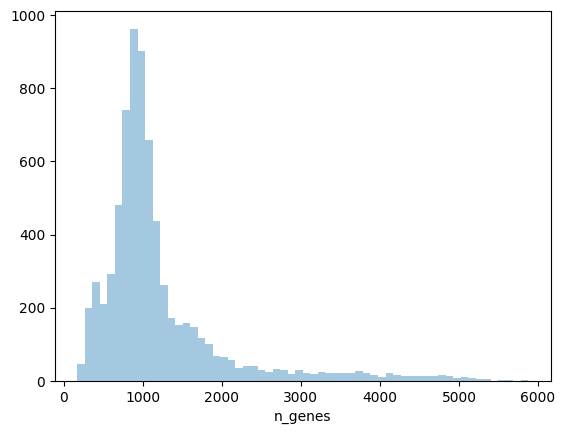

C:\Users\User\AppData\Local\Temp\ipykernel_10228\710109103.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p7 = sb.distplot(adata.obs['n_genes'][adata.obs['n_genes'] < 1000], kde=False, bins=60)


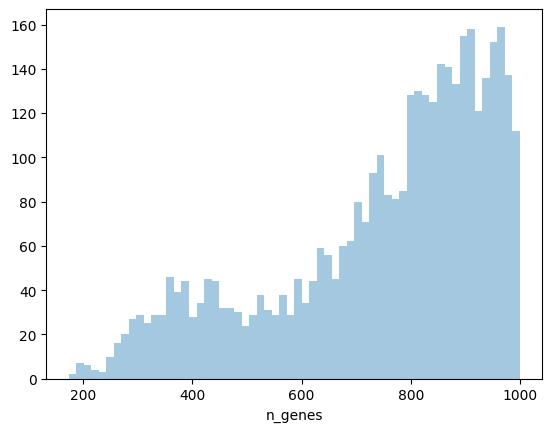

In [21]:
#Thresholding decision: genes
p6 = sb.distplot(adata.obs['n_genes'], kde=False, bins=60)
plt.show()

p7 = sb.distplot(adata.obs['n_genes'][adata.obs['n_genes'] < 1000], kde=False, bins=60)
plt.show()

In [22]:
# Filter cells according to identified QC thresholds:
print('Total number of cells: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes = 400)
print('Number of cells after min genes filter: {:d}'.format(adata.n_obs))

Total number of cells: 7172


C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scanpy\preprocessing\_simple.py:139: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['n_genes'] = number


Number of cells after min genes filter: 6825


C:\Users\User\AppData\Local\Temp\ipykernel_10228\1808565410.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(adata.obs['mt_frac'][adata.obs['mt_frac'] < 0.05], kde=False, bins=60)


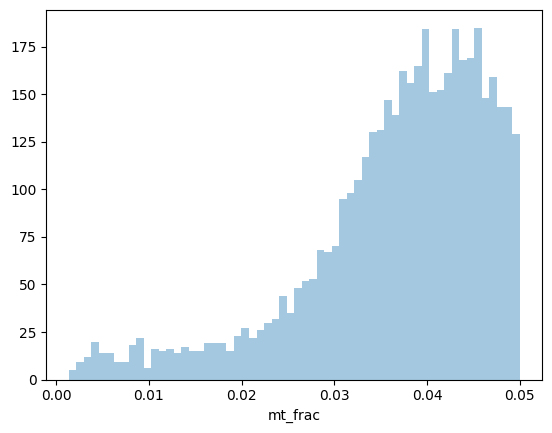

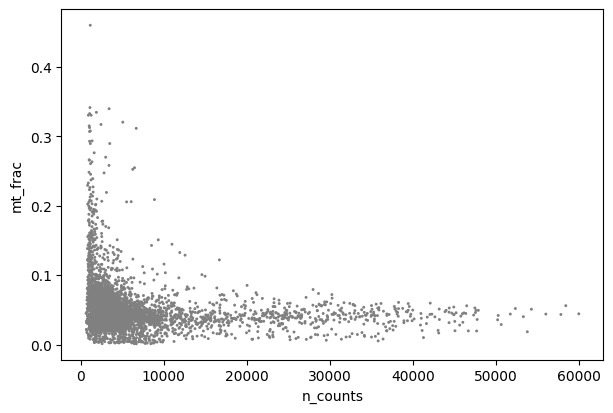

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scanpy\plotting\_utils.py:716: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  color = color[sort]


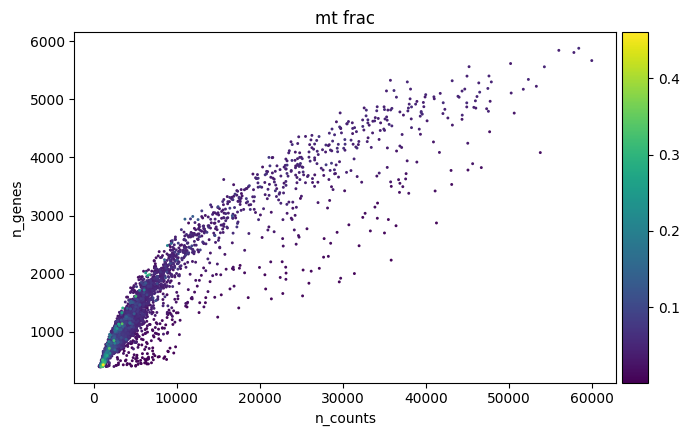

In [23]:
sb.distplot(adata.obs['mt_frac'][adata.obs['mt_frac'] < 0.05], kde=False, bins=60)
plt.show()
sc.pl.scatter(adata, x='n_counts', y='mt_frac')
sc.pl.scatter(adata, x='n_counts', y='n_genes', color='mt_frac')

In [24]:
# Thresholding on number of counts and percent_mito
print('Total number of cells: {:d}'.format(adata.n_obs))
adata = adata[(adata.obs['mt_frac'] > 0.01) | (adata.obs['n_counts'] > 10000)]

print('Number of cells after filter: {:d}'.format(adata.n_obs))

Total number of cells: 6825
Number of cells after filter: 6704


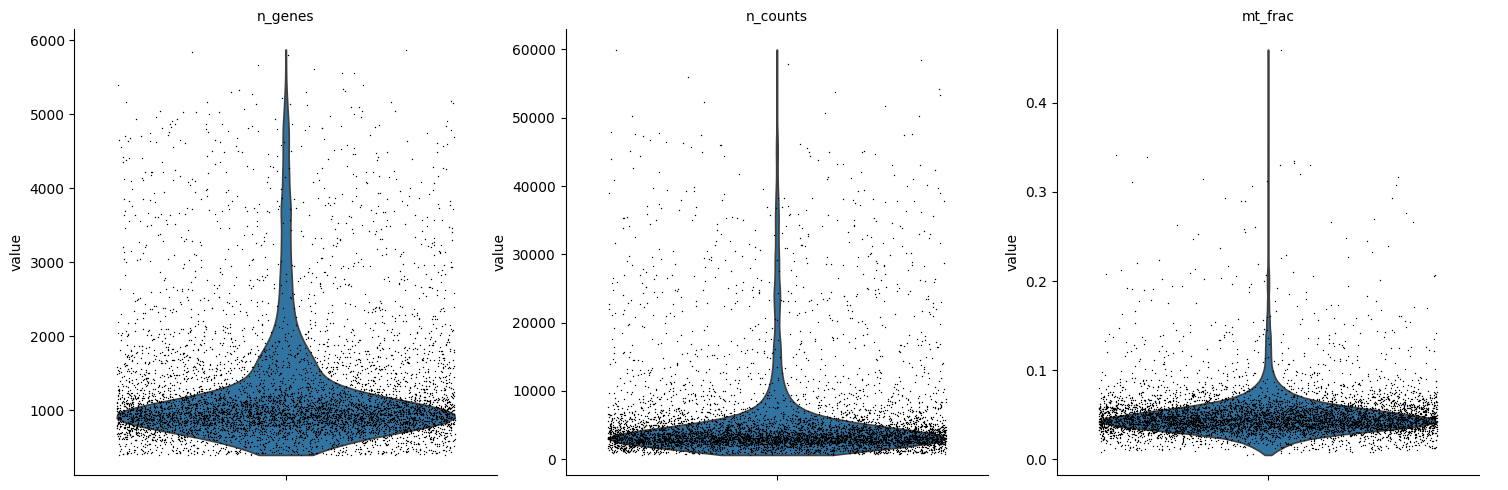

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scanpy\plotting\_utils.py:716: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  color = color[sort]


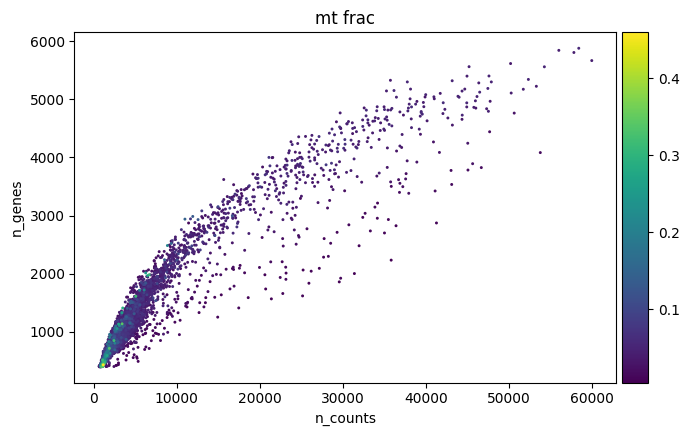

In [25]:
# visualise QC metrics after filtering
sc.pl.violin(adata, ['n_genes', 'n_counts', 'mt_frac'], jitter=0.4, multi_panel=True)
sc.pl.scatter(adata, x='n_counts', y='n_genes', color='mt_frac')

In [26]:
adata.obs['sample'] = 'ND_090617'
adata.obs['timepoint'] = 'Healthy'
adatas.append(adata)

C:\Users\User\AppData\Local\Temp\ipykernel_10228\1668133570.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['sample'] = 'ND_090617'


In [27]:
adata = sc.read('../data/petti/Normal_sorted_170531.matrix.mtx').T
adata.obs_names = pd.read_csv('../data/petti/Normal_sorted_170531.barcodes.tsv', delimiter='\t', header=None)[0].values
adata.var_names = pd.read_csv('../data/petti/Normal_sorted_170531.genes.tsv', delimiter='\t', header=None)[1]
adata

AnnData object with n_obs × n_vars = 3137 × 33538

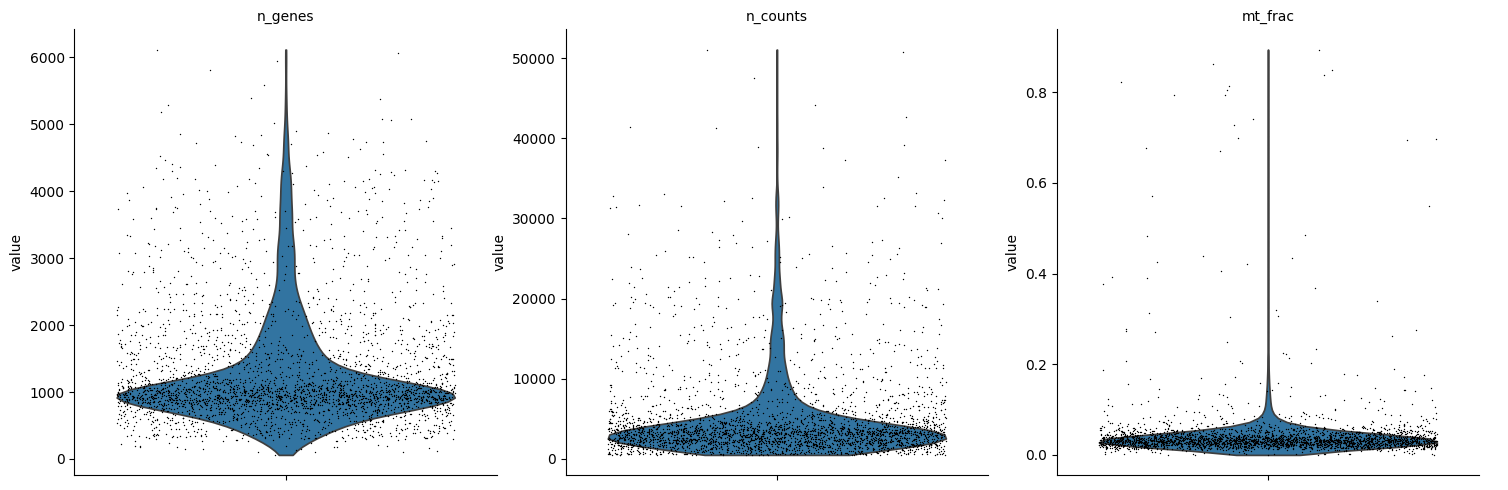

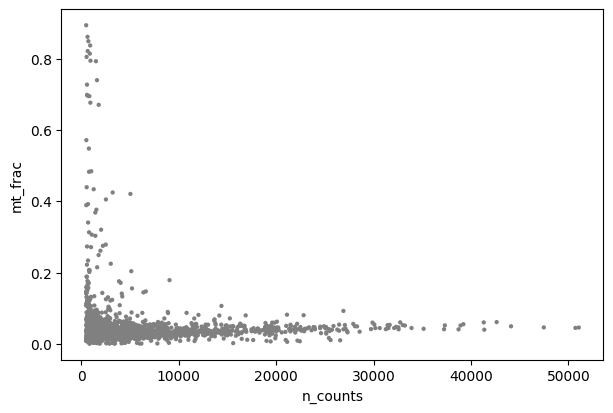

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scanpy\plotting\_utils.py:716: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  color = color[sort]


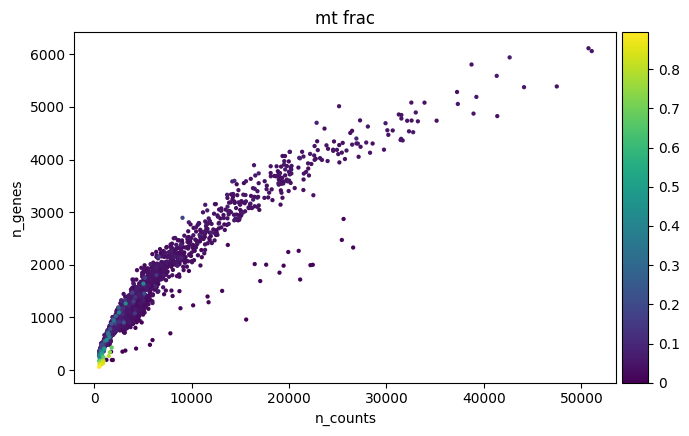

In [28]:
# Quality control - calculate QC covariates
adata.var_names_make_unique()
adata.obs['n_counts'] = adata.X.sum(1)
adata.obs['log_counts'] = np.log(adata.obs['n_counts'])
adata.obs['n_genes'] = (adata.X > 0).sum(1)

adata.X = adata.X.toarray()
mt_gene_mask = [gene.startswith('MT-') for gene in adata.var_names]
adata.obs['mt_frac'] = adata.X[:, mt_gene_mask].sum(1)/adata.obs['n_counts']

# Quality control - plot QC metrics
sc.pl.violin(adata, ['n_genes', 'n_counts', 'mt_frac'],
             jitter=0.4, multi_panel=True)

sc.pl.scatter(adata, x='n_counts', y='mt_frac')
sc.pl.scatter(adata, x='n_counts', y='n_genes', color='mt_frac')

C:\Users\User\AppData\Local\Temp\ipykernel_10228\2253007655.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p3 = sb.distplot(adata.obs['n_counts'], kde=False)


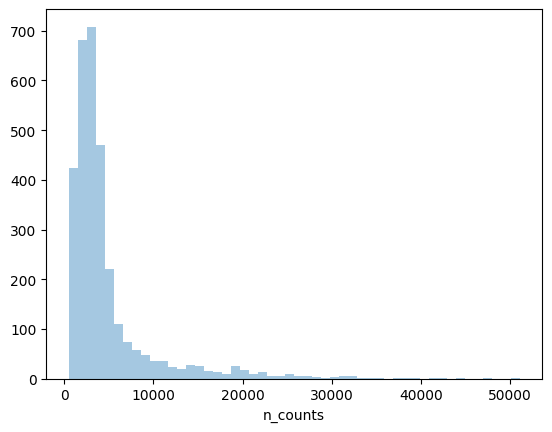

C:\Users\User\AppData\Local\Temp\ipykernel_10228\2253007655.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p4 = sb.distplot(adata.obs['n_counts'][adata.obs['n_counts']<10000], kde=False, bins=60)


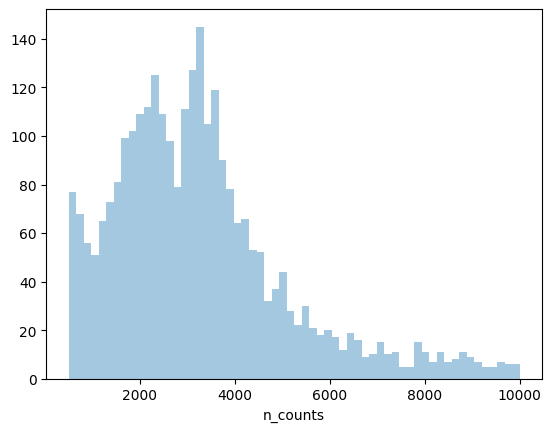

C:\Users\User\AppData\Local\Temp\ipykernel_10228\2253007655.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p5 = sb.distplot(adata.obs['n_counts'][adata.obs['n_counts']>10000], kde=False, bins=60)


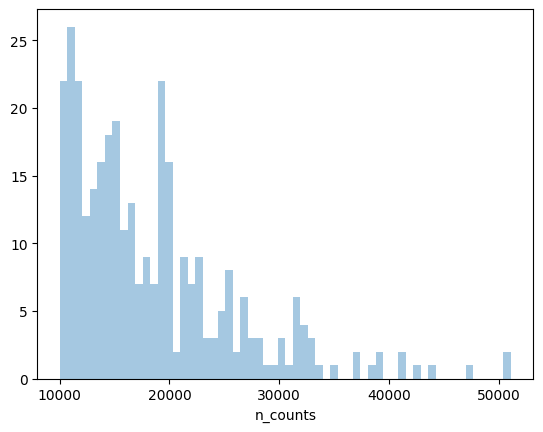

In [29]:
#Thresholding decision: counts
p3 = sb.distplot(adata.obs['n_counts'], kde=False)
plt.show()

p4 = sb.distplot(adata.obs['n_counts'][adata.obs['n_counts']<10000], kde=False, bins=60)
plt.show()

p5 = sb.distplot(adata.obs['n_counts'][adata.obs['n_counts']>10000], kde=False, bins=60)
plt.show()

In [30]:
# Filter cells according to identified QC thresholds:
print('Total number of cells: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, max_counts = 40000)
print('Number of cells after max count filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['mt_frac'] < 0.5]
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Total number of cells: 3137
Number of cells after max count filter: 3130
Number of cells after MT filter: 3112


C:\Users\User\AppData\Local\Temp\ipykernel_10228\710109103.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p6 = sb.distplot(adata.obs['n_genes'], kde=False, bins=60)


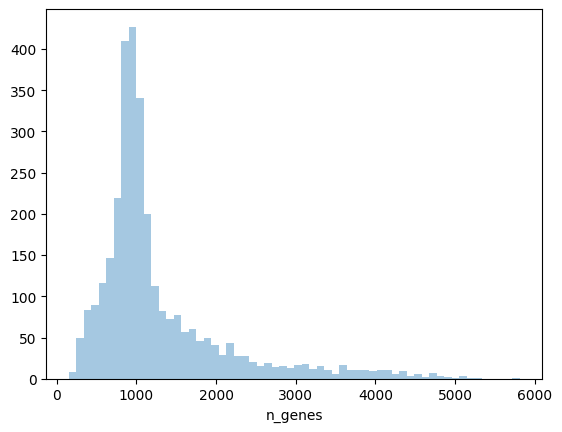

C:\Users\User\AppData\Local\Temp\ipykernel_10228\710109103.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p7 = sb.distplot(adata.obs['n_genes'][adata.obs['n_genes'] < 1000], kde=False, bins=60)


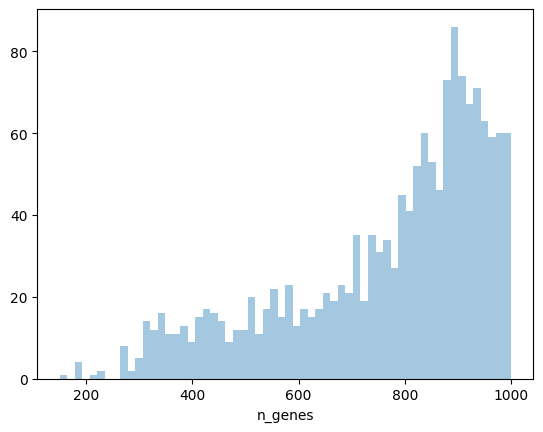

In [31]:
#Thresholding decision: genes
p6 = sb.distplot(adata.obs['n_genes'], kde=False, bins=60)
plt.show()

p7 = sb.distplot(adata.obs['n_genes'][adata.obs['n_genes'] < 1000], kde=False, bins=60)
plt.show()

In [32]:
# Filter cells according to identified QC thresholds:
print('Total number of cells: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes = 400)
print('Number of cells after min genes filter: {:d}'.format(adata.n_obs))

Total number of cells: 3112


C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scanpy\preprocessing\_simple.py:139: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['n_genes'] = number


Number of cells after min genes filter: 3008


C:\Users\User\AppData\Local\Temp\ipykernel_10228\1808565410.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(adata.obs['mt_frac'][adata.obs['mt_frac'] < 0.05], kde=False, bins=60)


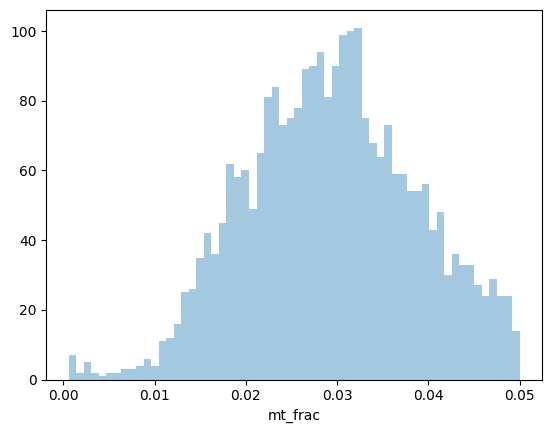

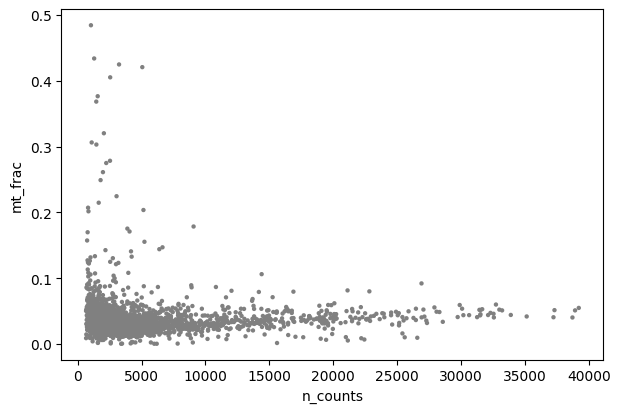

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scanpy\plotting\_utils.py:716: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  color = color[sort]


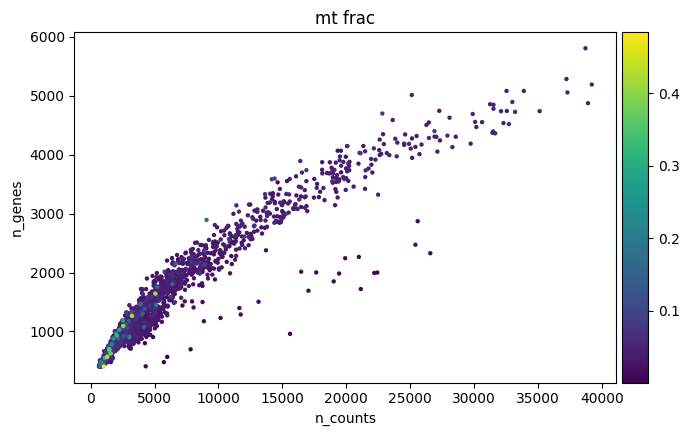

In [33]:
sb.distplot(adata.obs['mt_frac'][adata.obs['mt_frac'] < 0.05], kde=False, bins=60)
plt.show()
sc.pl.scatter(adata, x='n_counts', y='mt_frac')
sc.pl.scatter(adata, x='n_counts', y='n_genes', color='mt_frac')

In [34]:
# Thresholding on number of counts and percent_mito
print('Total number of cells: {:d}'.format(adata.n_obs))
adata = adata[(adata.obs['mt_frac'] > 0.01) | (adata.obs['n_counts'] > 7500)]

print('Number of cells after filter: {:d}'.format(adata.n_obs))

Total number of cells: 3008
Number of cells after filter: 2982


In [35]:
adata.obs['sample'] = 'Normal_sorted_170531'
adata.obs['timepoint'] = 'Healthy'
adatas.append(adata)

C:\Users\User\AppData\Local\Temp\ipykernel_10228\3981987427.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['sample'] = 'Normal_sorted_170531'


In [36]:
adata = sc.read('../data/petti/Normal_sorted_170607.matrix.mtx').T
adata.obs_names = pd.read_csv('../data/petti/Normal_sorted_170607.barcodes.tsv', delimiter='\t', header=None)[0].values
adata.var_names = pd.read_csv('../data/petti/Normal_sorted_170607.genes.tsv', delimiter='\t', header=None)[1]
adata

AnnData object with n_obs × n_vars = 3605 × 33538

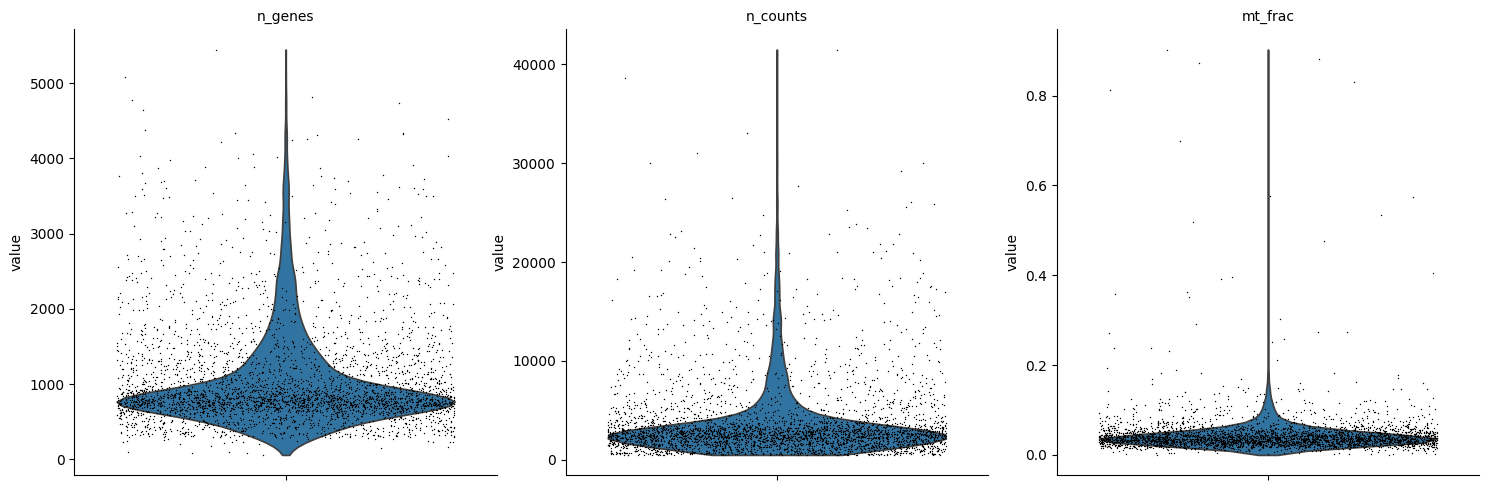

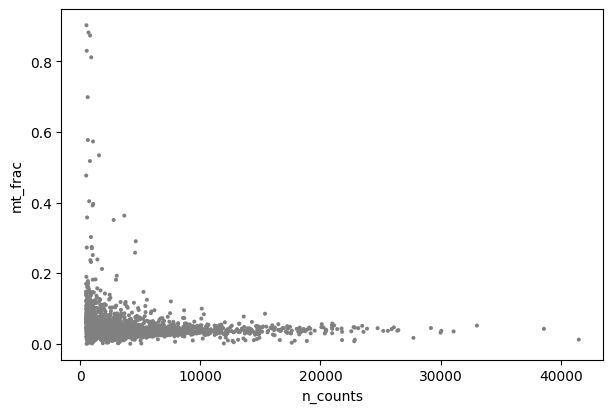

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scanpy\plotting\_utils.py:716: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  color = color[sort]


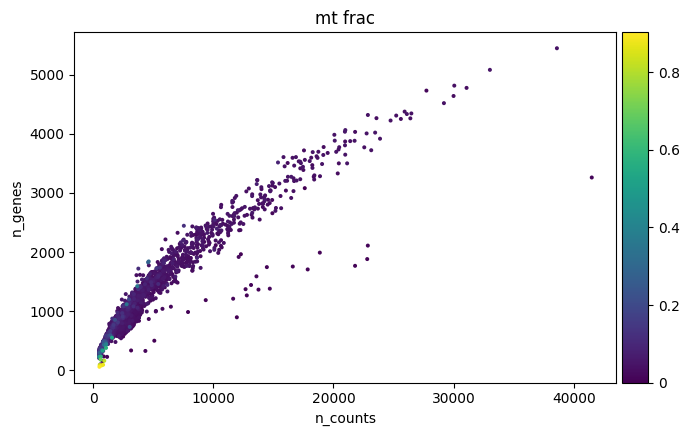

In [37]:
# Quality control - calculate QC covariates
adata.var_names_make_unique()
adata.obs['n_counts'] = adata.X.sum(1)
adata.obs['log_counts'] = np.log(adata.obs['n_counts'])
adata.obs['n_genes'] = (adata.X > 0).sum(1)

adata.X = adata.X.toarray()
mt_gene_mask = [gene.startswith('MT-') for gene in adata.var_names]
adata.obs['mt_frac'] = adata.X[:, mt_gene_mask].sum(1)/adata.obs['n_counts']

# Quality control - plot QC metrics
sc.pl.violin(adata, ['n_genes', 'n_counts', 'mt_frac'],
             jitter=0.4, multi_panel=True)

sc.pl.scatter(adata, x='n_counts', y='mt_frac')
sc.pl.scatter(adata, x='n_counts', y='n_genes', color='mt_frac')

C:\Users\User\AppData\Local\Temp\ipykernel_10228\2253007655.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p3 = sb.distplot(adata.obs['n_counts'], kde=False)


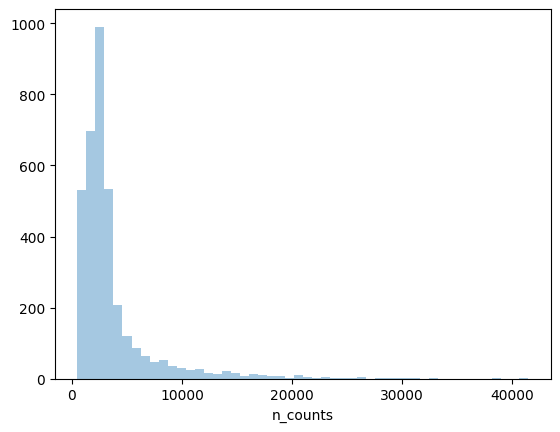

C:\Users\User\AppData\Local\Temp\ipykernel_10228\2253007655.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p4 = sb.distplot(adata.obs['n_counts'][adata.obs['n_counts']<10000], kde=False, bins=60)


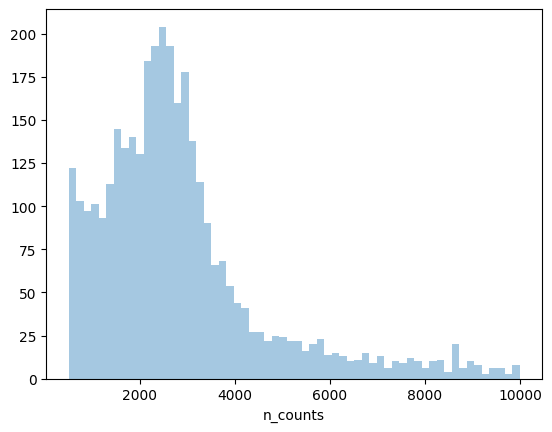

C:\Users\User\AppData\Local\Temp\ipykernel_10228\2253007655.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p5 = sb.distplot(adata.obs['n_counts'][adata.obs['n_counts']>10000], kde=False, bins=60)


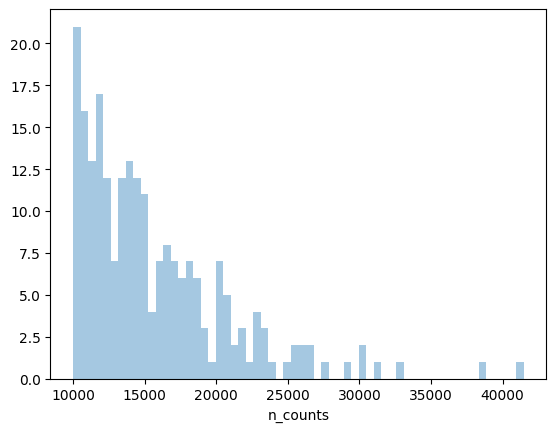

In [38]:
#Thresholding decision: counts
p3 = sb.distplot(adata.obs['n_counts'], kde=False)
plt.show()

p4 = sb.distplot(adata.obs['n_counts'][adata.obs['n_counts']<10000], kde=False, bins=60)
plt.show()

p5 = sb.distplot(adata.obs['n_counts'][adata.obs['n_counts']>10000], kde=False, bins=60)
plt.show()

In [39]:
# Filter cells according to identified QC thresholds:
print('Total number of cells: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, max_counts = 40000)
print('Number of cells after max count filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['mt_frac'] < 0.5]
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Total number of cells: 3605
Number of cells after max count filter: 3604
Number of cells after MT filter: 3594


C:\Users\User\AppData\Local\Temp\ipykernel_10228\710109103.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p6 = sb.distplot(adata.obs['n_genes'], kde=False, bins=60)


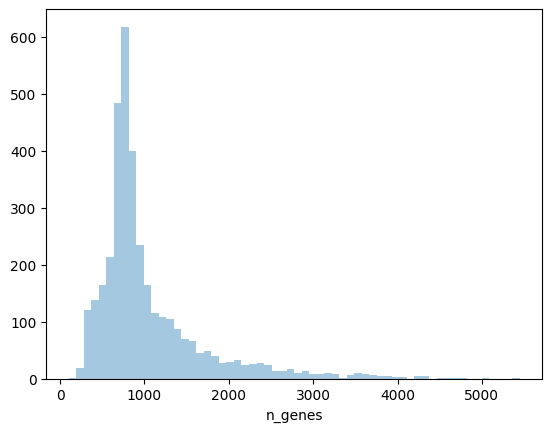

C:\Users\User\AppData\Local\Temp\ipykernel_10228\710109103.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p7 = sb.distplot(adata.obs['n_genes'][adata.obs['n_genes'] < 1000], kde=False, bins=60)


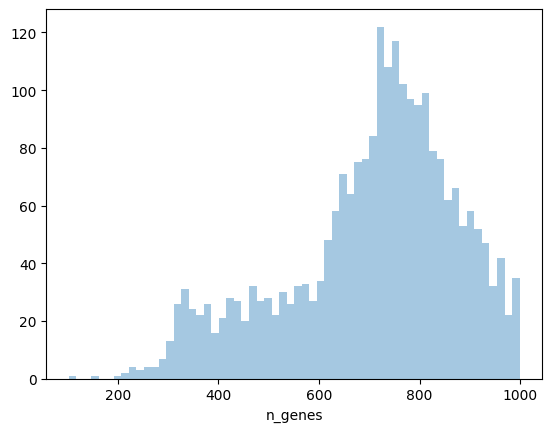

In [40]:
#Thresholding decision: genes
p6 = sb.distplot(adata.obs['n_genes'], kde=False, bins=60)
plt.show()

p7 = sb.distplot(adata.obs['n_genes'][adata.obs['n_genes'] < 1000], kde=False, bins=60)
plt.show()

In [41]:
# Filter cells according to identified QC thresholds:
print('Total number of cells: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes = 400)
print('Number of cells after min genes filter: {:d}'.format(adata.n_obs))

Total number of cells: 3594


C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scanpy\preprocessing\_simple.py:139: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['n_genes'] = number


Number of cells after min genes filter: 3410


C:\Users\User\AppData\Local\Temp\ipykernel_10228\1808565410.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(adata.obs['mt_frac'][adata.obs['mt_frac'] < 0.05], kde=False, bins=60)


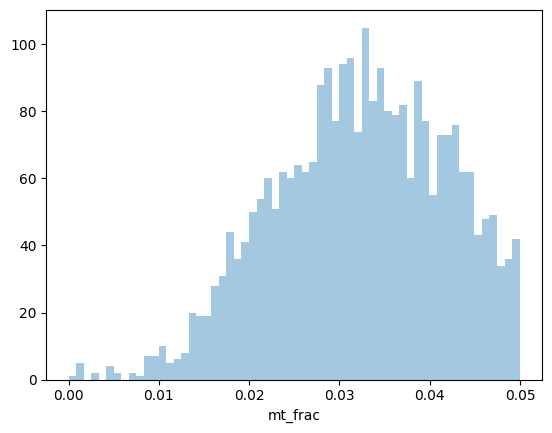

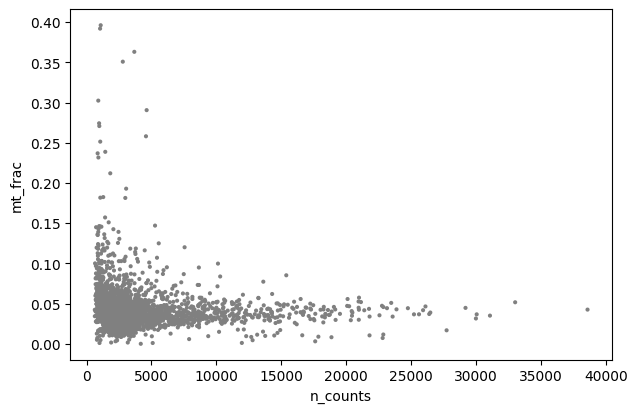

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scanpy\plotting\_utils.py:716: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  color = color[sort]


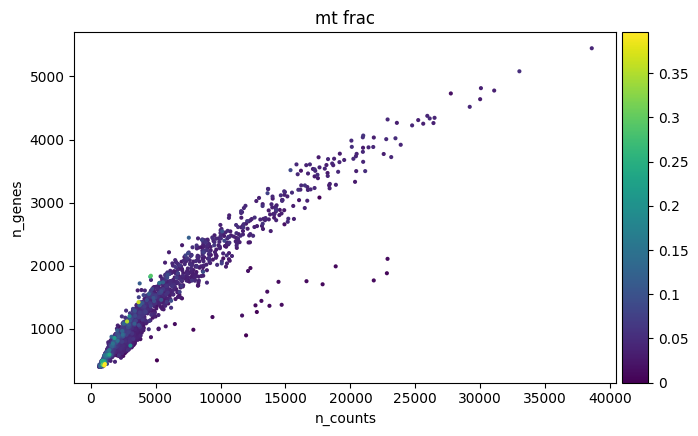

In [42]:
sb.distplot(adata.obs['mt_frac'][adata.obs['mt_frac'] < 0.05], kde=False, bins=60)
plt.show()
sc.pl.scatter(adata, x='n_counts', y='mt_frac')
sc.pl.scatter(adata, x='n_counts', y='n_genes', color='mt_frac')

In [43]:
# Thresholding on number of counts and percent_mito
print('Total number of cells: {:d}'.format(adata.n_obs))
adata = adata[(adata.obs['mt_frac'] > 0.01) | (adata.obs['n_counts'] > 7500)]

print('Number of cells after filter: {:d}'.format(adata.n_obs))

Total number of cells: 3410
Number of cells after filter: 3390


In [44]:
adata.obs['sample'] = 'Normal_sorted_170607'
adata.obs['timepoint'] = 'Healthy'
adatas.append(adata)

C:\Users\User\AppData\Local\Temp\ipykernel_10228\2543507364.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['sample'] = 'Normal_sorted_170607'


Now move on to the AML samples.

In [45]:
adata = sc.read('../data/petti/508084.matrix.mtx').T
adata.obs_names = pd.read_csv('../data/petti/508084.barcodes.tsv', delimiter='\t', header=None)[0].values
adata.var_names = pd.read_csv('../data/petti/508084.genes.tsv', delimiter='\t', header=None)[1]
adata

AnnData object with n_obs × n_vars = 14964 × 33694

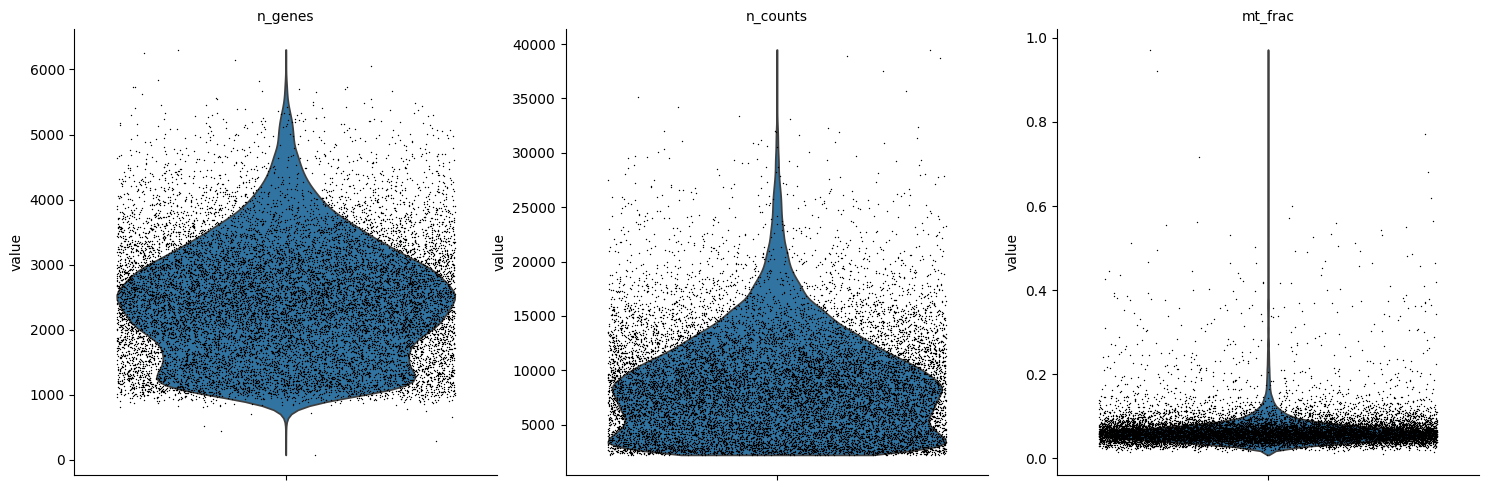

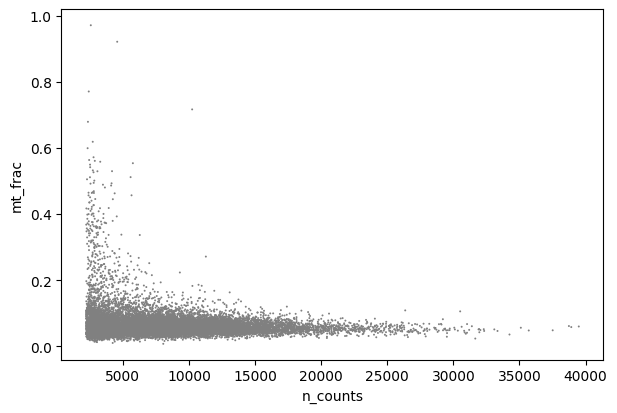

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scanpy\plotting\_utils.py:716: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  color = color[sort]


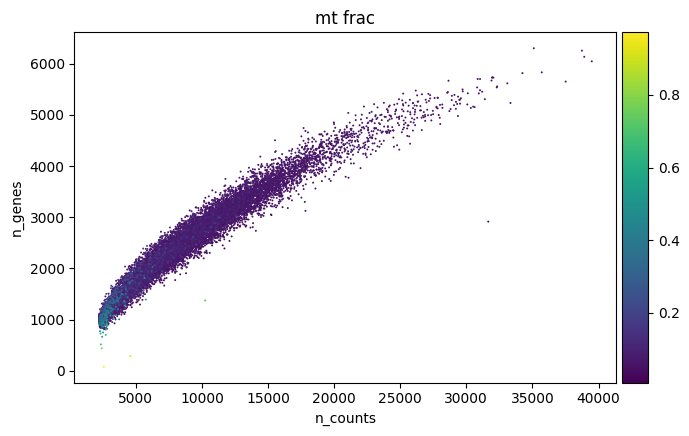

In [46]:
# Quality control - calculate QC covariates
adata.var_names_make_unique()
adata.obs['n_counts'] = adata.X.sum(1)
adata.obs['log_counts'] = np.log(adata.obs['n_counts'])
adata.obs['n_genes'] = (adata.X > 0).sum(1)

adata.X = adata.X.toarray()
mt_gene_mask = [gene.startswith('MT-') for gene in adata.var_names]
adata.obs['mt_frac'] = adata.X[:, mt_gene_mask].sum(1)/adata.obs['n_counts']

# Quality control - plot QC metrics
sc.pl.violin(adata, ['n_genes', 'n_counts', 'mt_frac'],
             jitter=0.4, multi_panel=True)

sc.pl.scatter(adata, x='n_counts', y='mt_frac')
sc.pl.scatter(adata, x='n_counts', y='n_genes', color='mt_frac')

C:\Users\User\AppData\Local\Temp\ipykernel_10228\2253007655.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p3 = sb.distplot(adata.obs['n_counts'], kde=False)


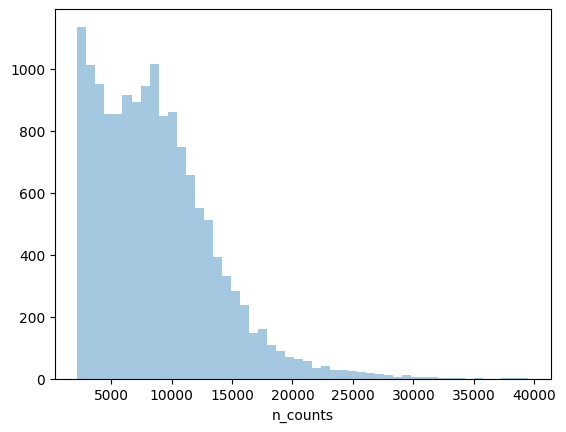

C:\Users\User\AppData\Local\Temp\ipykernel_10228\2253007655.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p4 = sb.distplot(adata.obs['n_counts'][adata.obs['n_counts']<10000], kde=False, bins=60)


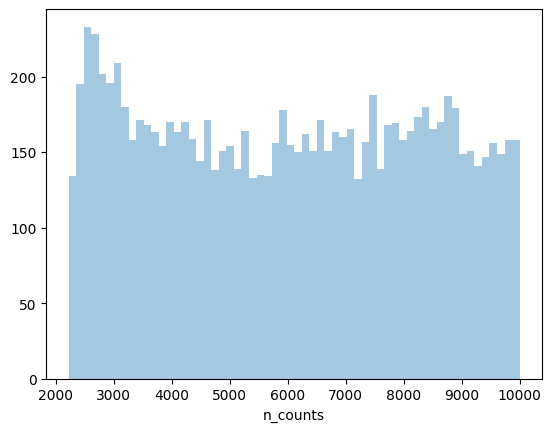

C:\Users\User\AppData\Local\Temp\ipykernel_10228\2253007655.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p5 = sb.distplot(adata.obs['n_counts'][adata.obs['n_counts']>10000], kde=False, bins=60)


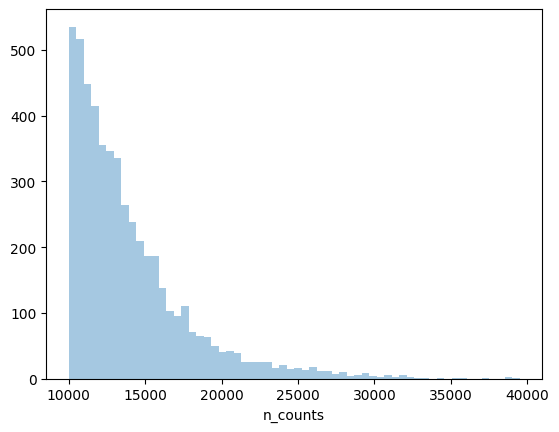

In [47]:
#Thresholding decision: counts
p3 = sb.distplot(adata.obs['n_counts'], kde=False)
plt.show()

p4 = sb.distplot(adata.obs['n_counts'][adata.obs['n_counts']<10000], kde=False, bins=60)
plt.show()

p5 = sb.distplot(adata.obs['n_counts'][adata.obs['n_counts']>10000], kde=False, bins=60)
plt.show()

In [48]:
# Filter cells according to identified QC thresholds:
print('Total number of cells: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, max_counts = 37000)
print('Number of cells after max count filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['mt_frac'] < 0.5]
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Total number of cells: 14964
Number of cells after max count filter: 14960
Number of cells after MT filter: 14938


C:\Users\User\AppData\Local\Temp\ipykernel_10228\3843457561.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p6 = sb.distplot(adata.obs['n_genes'], kde=False, bins=60)


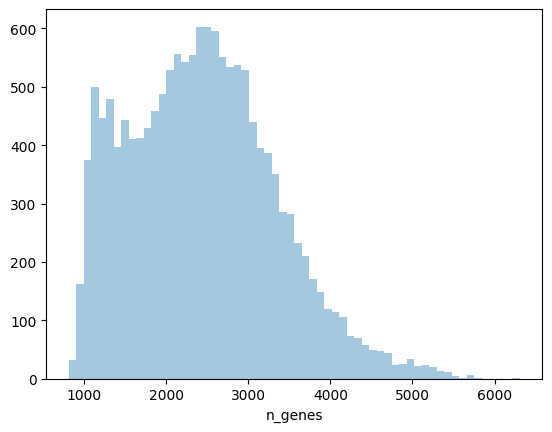

C:\Users\User\AppData\Local\Temp\ipykernel_10228\3843457561.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p7 = sb.distplot(adata.obs['n_genes'][adata.obs['n_genes'] < 2000], kde=False, bins=60)


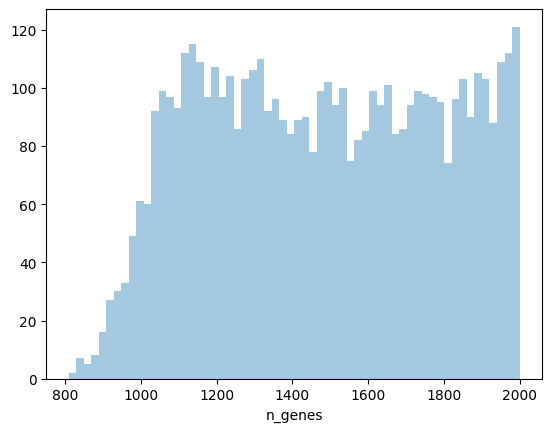

In [49]:
#Thresholding decision: genes
p6 = sb.distplot(adata.obs['n_genes'], kde=False, bins=60)
plt.show()

p7 = sb.distplot(adata.obs['n_genes'][adata.obs['n_genes'] < 2000], kde=False, bins=60)
plt.show()

In [50]:
# Filter cells according to identified QC thresholds:
print('Total number of cells: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes = 400)
print('Number of cells after min genes filter: {:d}'.format(adata.n_obs))

Total number of cells: 14938


C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scanpy\preprocessing\_simple.py:139: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['n_genes'] = number


Number of cells after min genes filter: 14938


C:\Users\User\AppData\Local\Temp\ipykernel_10228\1808565410.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(adata.obs['mt_frac'][adata.obs['mt_frac'] < 0.05], kde=False, bins=60)


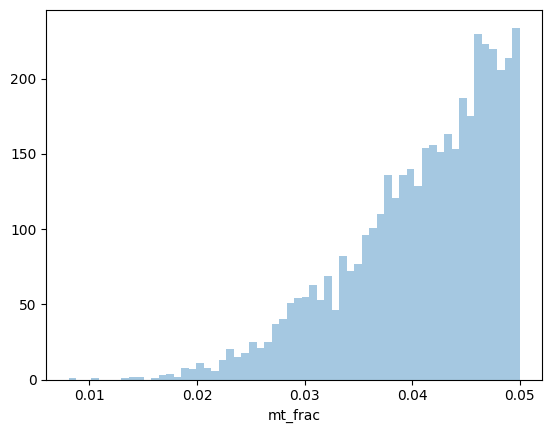

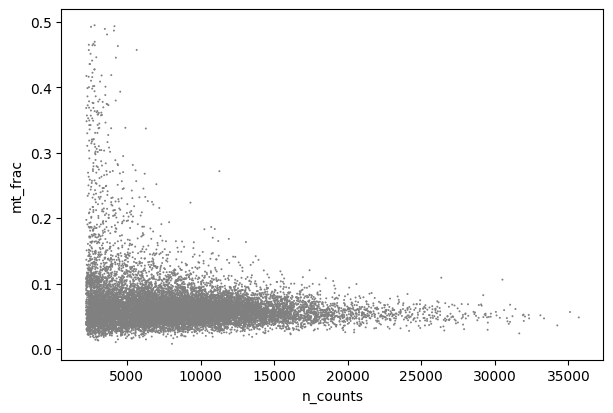

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scanpy\plotting\_utils.py:716: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  color = color[sort]


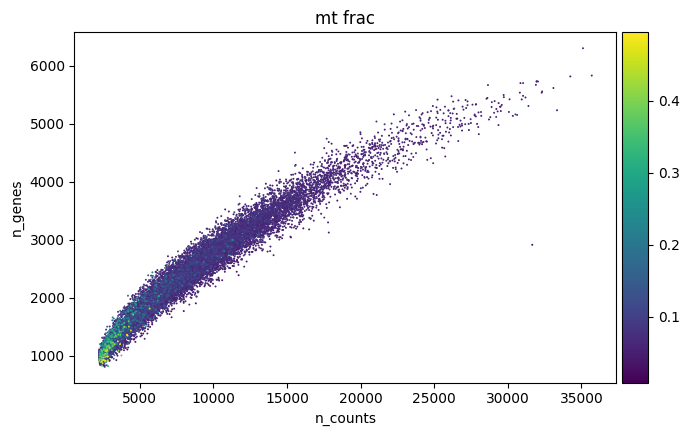

In [51]:
sb.distplot(adata.obs['mt_frac'][adata.obs['mt_frac'] < 0.05], kde=False, bins=60)
plt.show()
sc.pl.scatter(adata, x='n_counts', y='mt_frac')
sc.pl.scatter(adata, x='n_counts', y='n_genes', color='mt_frac')

In [52]:
# Thresholding on number of counts and percent_mito
print('Total number of cells: {:d}'.format(adata.n_obs))
adata = adata[(adata.obs['mt_frac'] > 0.01) | (adata.obs['n_counts'] > 7500)]

print('Number of cells after filter: {:d}'.format(adata.n_obs))

Total number of cells: 14938
Number of cells after filter: 14938


In [53]:
adata.obs['sample'] = '508084'
adata.obs['timepoint'] = 'Diagnosis'
adatas.append(adata)

C:\Users\User\AppData\Local\Temp\ipykernel_10228\2928181835.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['sample'] = '508084'


In [54]:
adata = sc.read('../data/petti/548327.matrix.mtx').T
adata.obs_names = pd.read_csv('../data/petti/548327.barcodes.tsv', delimiter='\t', header=None)[0].values
adata.var_names = pd.read_csv('../data/petti/548327.genes.tsv', delimiter='\t', header=None)[1]
adata

AnnData object with n_obs × n_vars = 11620 × 33694

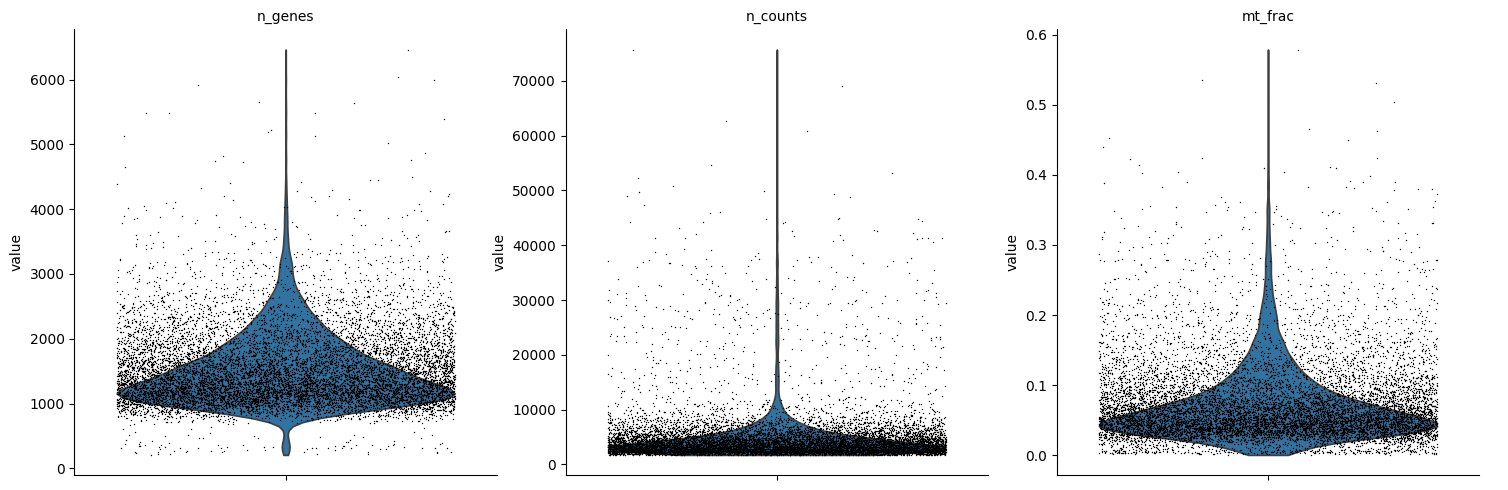

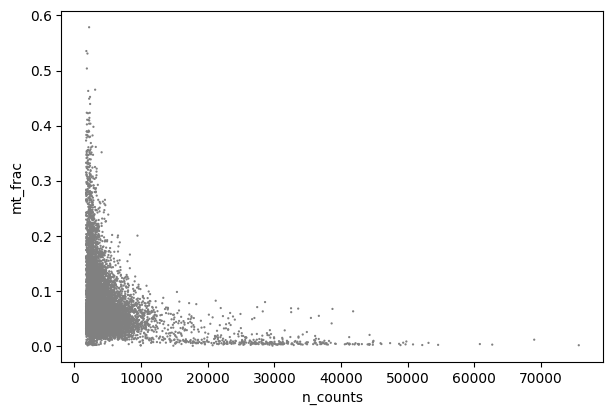

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scanpy\plotting\_utils.py:716: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  color = color[sort]


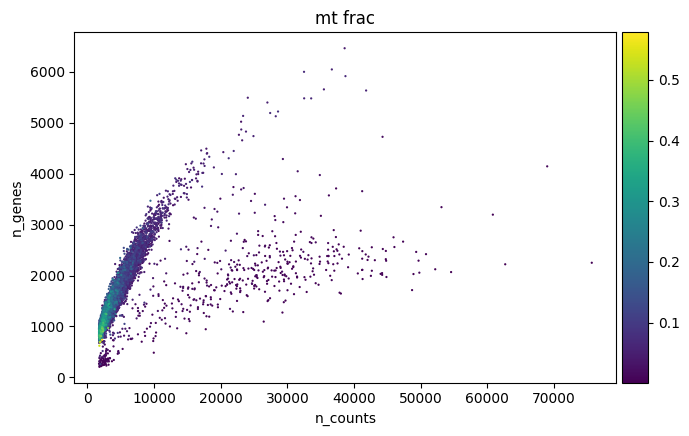

In [55]:
# Quality control - calculate QC covariates
adata.var_names_make_unique()
adata.obs['n_counts'] = adata.X.sum(1)
adata.obs['log_counts'] = np.log(adata.obs['n_counts'])
adata.obs['n_genes'] = (adata.X > 0).sum(1)

adata.X = adata.X.toarray()
mt_gene_mask = [gene.startswith('MT-') for gene in adata.var_names]
adata.obs['mt_frac'] = adata.X[:, mt_gene_mask].sum(1)/adata.obs['n_counts']

# Quality control - plot QC metrics
sc.pl.violin(adata, ['n_genes', 'n_counts', 'mt_frac'],
             jitter=0.4, multi_panel=True)

sc.pl.scatter(adata, x='n_counts', y='mt_frac')
sc.pl.scatter(adata, x='n_counts', y='n_genes', color='mt_frac')

C:\Users\User\AppData\Local\Temp\ipykernel_10228\2253007655.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p3 = sb.distplot(adata.obs['n_counts'], kde=False)


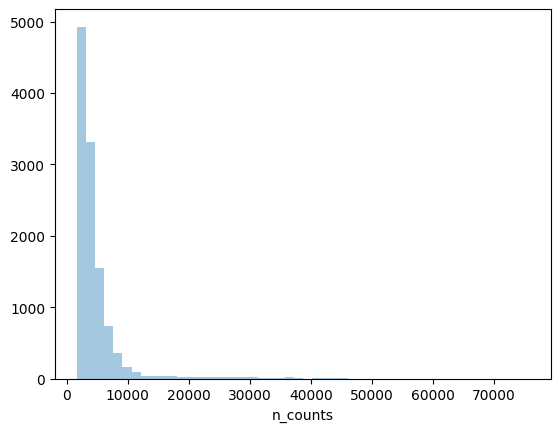

C:\Users\User\AppData\Local\Temp\ipykernel_10228\2253007655.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p4 = sb.distplot(adata.obs['n_counts'][adata.obs['n_counts']<10000], kde=False, bins=60)


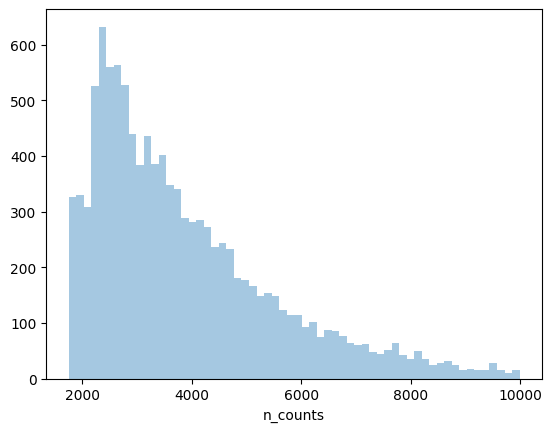

C:\Users\User\AppData\Local\Temp\ipykernel_10228\2253007655.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p5 = sb.distplot(adata.obs['n_counts'][adata.obs['n_counts']>10000], kde=False, bins=60)


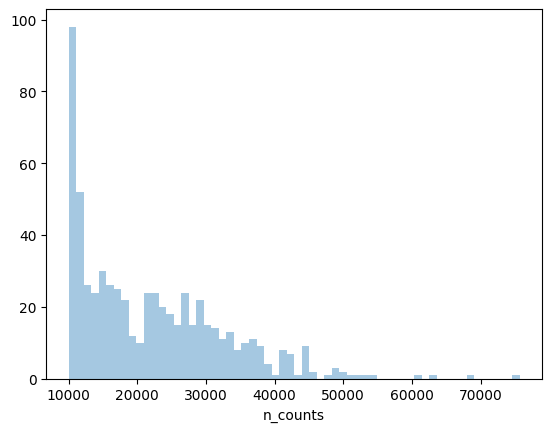

In [56]:
#Thresholding decision: counts
p3 = sb.distplot(adata.obs['n_counts'], kde=False)
plt.show()

p4 = sb.distplot(adata.obs['n_counts'][adata.obs['n_counts']<10000], kde=False, bins=60)
plt.show()

p5 = sb.distplot(adata.obs['n_counts'][adata.obs['n_counts']>10000], kde=False, bins=60)
plt.show()

In [57]:
# Filter cells according to identified QC thresholds:
print('Total number of cells: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, max_counts = 40000)
print('Number of cells after max count filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['mt_frac'] < 0.4]
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Total number of cells: 11620
Number of cells after max count filter: 11578
Number of cells after MT filter: 11559


C:\Users\User\AppData\Local\Temp\ipykernel_10228\710109103.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p6 = sb.distplot(adata.obs['n_genes'], kde=False, bins=60)


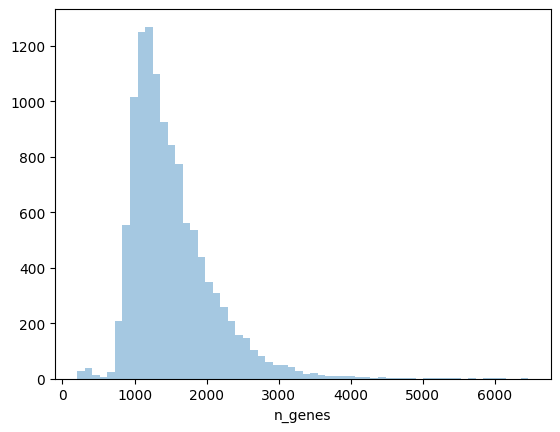

C:\Users\User\AppData\Local\Temp\ipykernel_10228\710109103.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p7 = sb.distplot(adata.obs['n_genes'][adata.obs['n_genes'] < 1000], kde=False, bins=60)


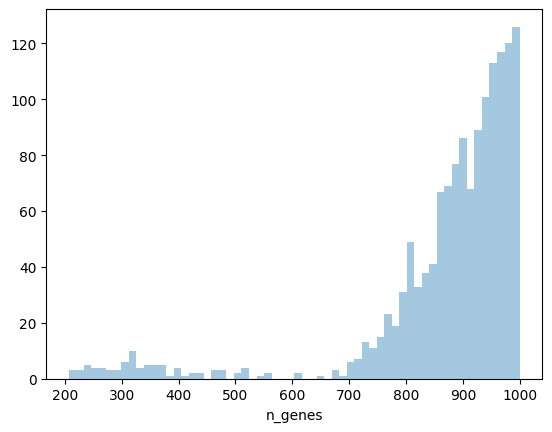

In [58]:
#Thresholding decision: genes
p6 = sb.distplot(adata.obs['n_genes'], kde=False, bins=60)
plt.show()

p7 = sb.distplot(adata.obs['n_genes'][adata.obs['n_genes'] < 1000], kde=False, bins=60)
plt.show()

In [59]:
# Filter cells according to identified QC thresholds:
print('Total number of cells: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes = 600)
print('Number of cells after min genes filter: {:d}'.format(adata.n_obs))

Total number of cells: 11559


C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scanpy\preprocessing\_simple.py:139: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['n_genes'] = number


Number of cells after min genes filter: 11474


C:\Users\User\AppData\Local\Temp\ipykernel_10228\1808565410.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(adata.obs['mt_frac'][adata.obs['mt_frac'] < 0.05], kde=False, bins=60)


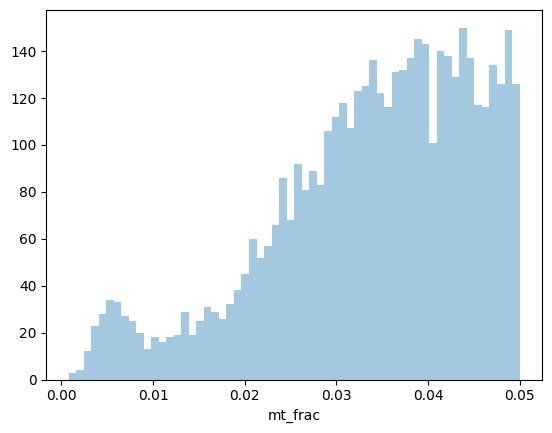

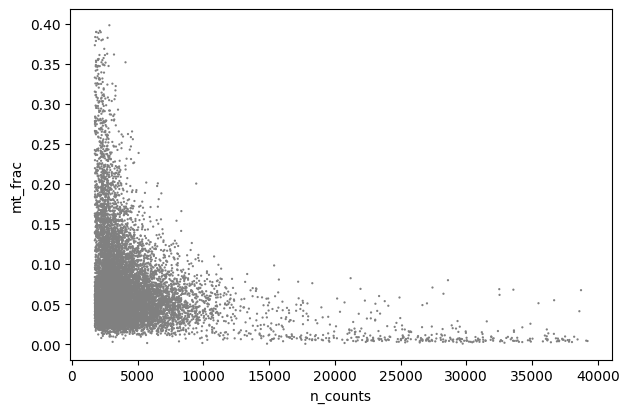

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scanpy\plotting\_utils.py:716: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  color = color[sort]


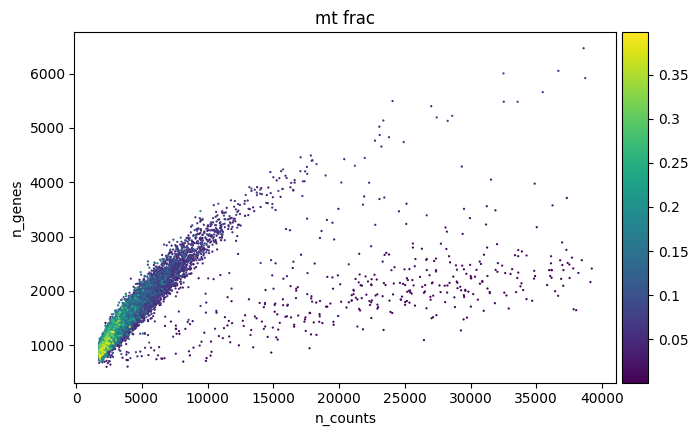

In [60]:
sb.distplot(adata.obs['mt_frac'][adata.obs['mt_frac'] < 0.05], kde=False, bins=60)
plt.show()
sc.pl.scatter(adata, x='n_counts', y='mt_frac')
sc.pl.scatter(adata, x='n_counts', y='n_genes', color='mt_frac')

In [61]:
# Thresholding on number of counts and percent_mito
print('Total number of cells: {:d}'.format(adata.n_obs))
adata = adata[(adata.obs['mt_frac'] > 0.01) | (adata.obs['n_counts'] > 40000)]

print('Number of cells after filter: {:d}'.format(adata.n_obs))

Total number of cells: 11474
Number of cells after filter: 11247


In [62]:
adata.obs['sample'] = '548327'
adata.obs['timepoint'] = 'Diagnosis'
adatas.append(adata)

C:\Users\User\AppData\Local\Temp\ipykernel_10228\3519586563.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['sample'] = '548327'


In [63]:
adata = sc.read('../data/petti/721214.matrix.mtx').T
adata.obs_names = pd.read_csv('../data/petti/721214.barcodes.tsv', delimiter='\t', header=None)[0].values
adata.var_names = pd.read_csv('../data/petti/721214.genes.tsv', delimiter='\t', header=None)[1]
adata

AnnData object with n_obs × n_vars = 20474 × 33694

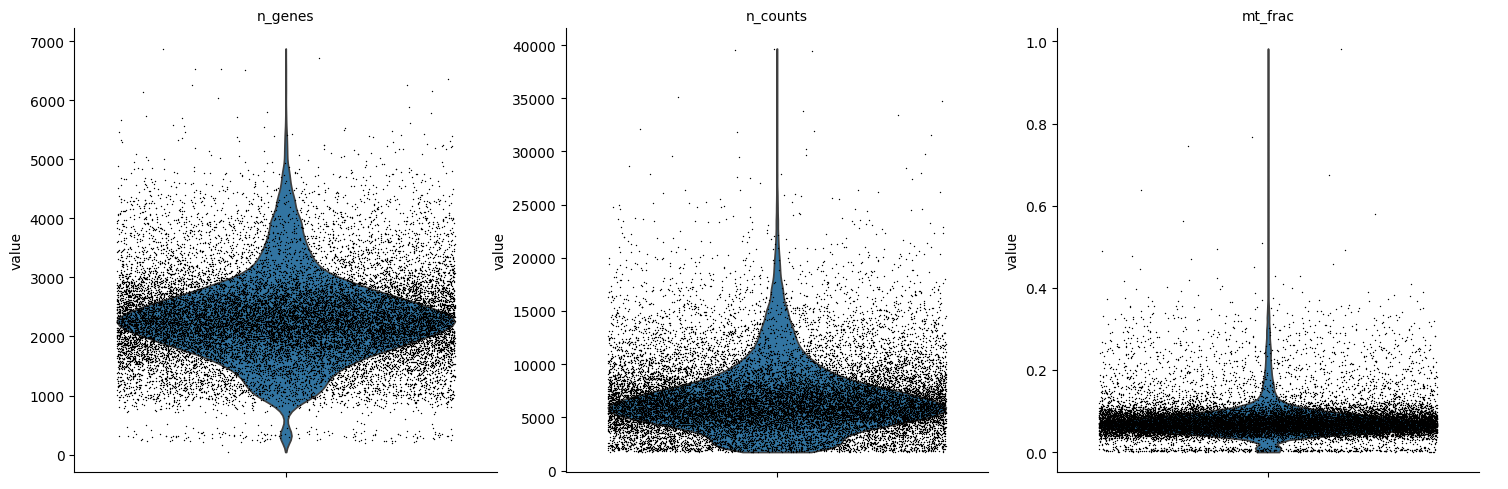

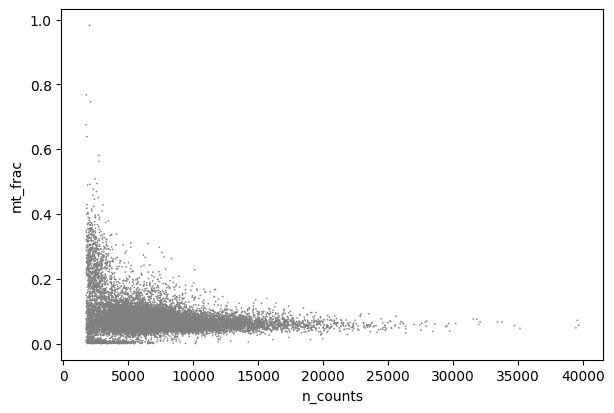

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scanpy\plotting\_utils.py:716: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  color = color[sort]


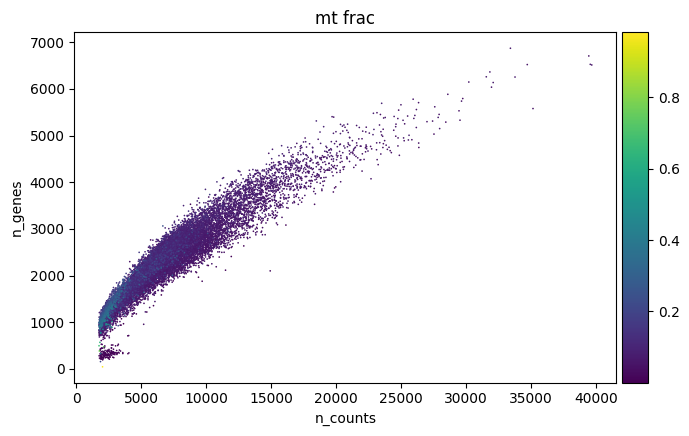

In [64]:
# Quality control - calculate QC covariates
adata.var_names_make_unique()
adata.obs['n_counts'] = adata.X.sum(1)
adata.obs['log_counts'] = np.log(adata.obs['n_counts'])
adata.obs['n_genes'] = (adata.X > 0).sum(1)

adata.X = adata.X.toarray()
mt_gene_mask = [gene.startswith('MT-') for gene in adata.var_names]
adata.obs['mt_frac'] = adata.X[:, mt_gene_mask].sum(1)/adata.obs['n_counts']

# Quality control - plot QC metrics
sc.pl.violin(adata, ['n_genes', 'n_counts', 'mt_frac'],
             jitter=0.4, multi_panel=True)

sc.pl.scatter(adata, x='n_counts', y='mt_frac')
sc.pl.scatter(adata, x='n_counts', y='n_genes', color='mt_frac')

C:\Users\User\AppData\Local\Temp\ipykernel_10228\2253007655.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p3 = sb.distplot(adata.obs['n_counts'], kde=False)


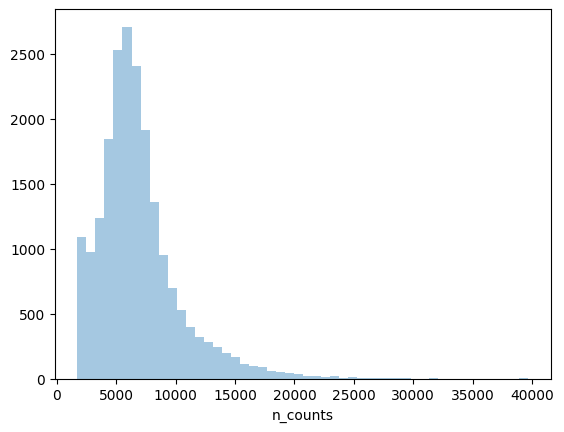

C:\Users\User\AppData\Local\Temp\ipykernel_10228\2253007655.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p4 = sb.distplot(adata.obs['n_counts'][adata.obs['n_counts']<10000], kde=False, bins=60)


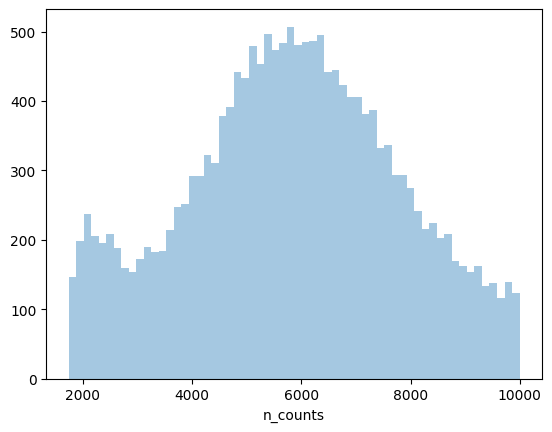

C:\Users\User\AppData\Local\Temp\ipykernel_10228\2253007655.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p5 = sb.distplot(adata.obs['n_counts'][adata.obs['n_counts']>10000], kde=False, bins=60)


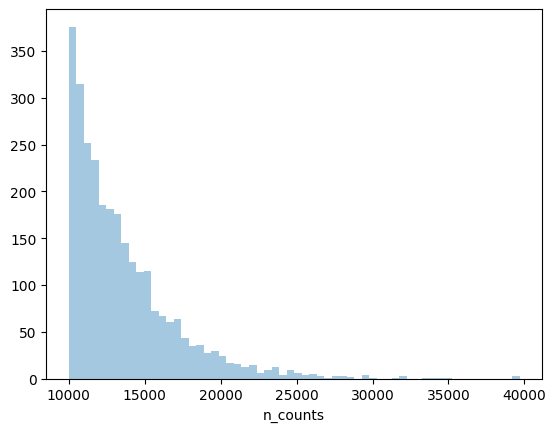

In [65]:
#Thresholding decision: counts
p3 = sb.distplot(adata.obs['n_counts'], kde=False)
plt.show()

p4 = sb.distplot(adata.obs['n_counts'][adata.obs['n_counts']<10000], kde=False, bins=60)
plt.show()

p5 = sb.distplot(adata.obs['n_counts'][adata.obs['n_counts']>10000], kde=False, bins=60)
plt.show()

In [66]:
# Filter cells according to identified QC thresholds:
print('Total number of cells: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, max_counts = 30000)
print('Number of cells after max count filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['mt_frac'] < 0.5]
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Total number of cells: 20474
Number of cells after max count filter: 20462
Number of cells after MT filter: 20454


C:\Users\User\AppData\Local\Temp\ipykernel_10228\710109103.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p6 = sb.distplot(adata.obs['n_genes'], kde=False, bins=60)


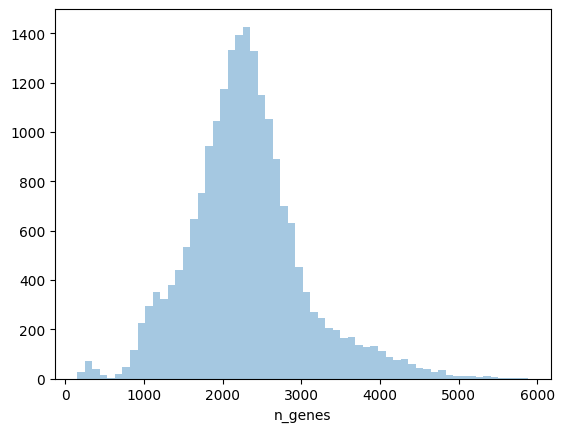

C:\Users\User\AppData\Local\Temp\ipykernel_10228\710109103.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p7 = sb.distplot(adata.obs['n_genes'][adata.obs['n_genes'] < 1000], kde=False, bins=60)


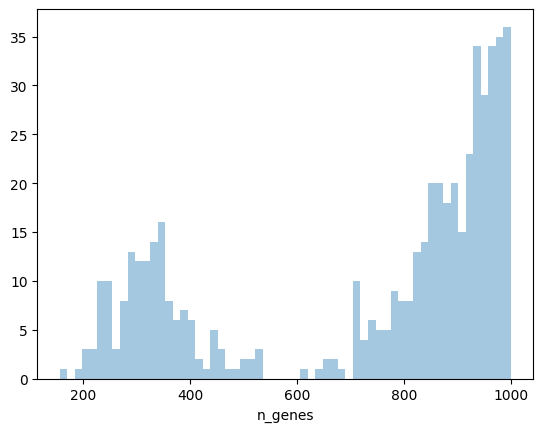

In [67]:
#Thresholding decision: genes
p6 = sb.distplot(adata.obs['n_genes'], kde=False, bins=60)
plt.show()

p7 = sb.distplot(adata.obs['n_genes'][adata.obs['n_genes'] < 1000], kde=False, bins=60)
plt.show()

In [68]:
# Filter cells according to identified QC thresholds:
print('Total number of cells: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes = 600)
print('Number of cells after min genes filter: {:d}'.format(adata.n_obs))

Total number of cells: 20454


C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scanpy\preprocessing\_simple.py:139: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['n_genes'] = number


Number of cells after min genes filter: 20301


C:\Users\User\AppData\Local\Temp\ipykernel_10228\1808565410.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(adata.obs['mt_frac'][adata.obs['mt_frac'] < 0.05], kde=False, bins=60)


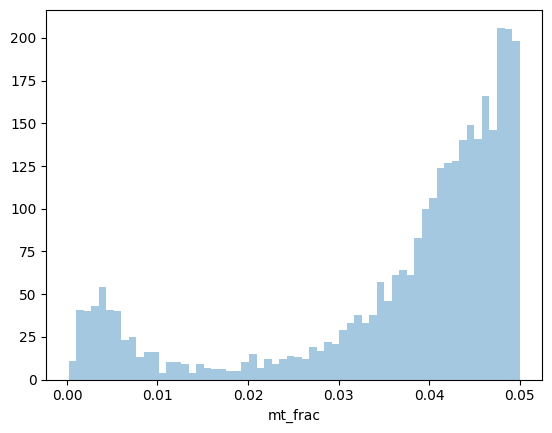

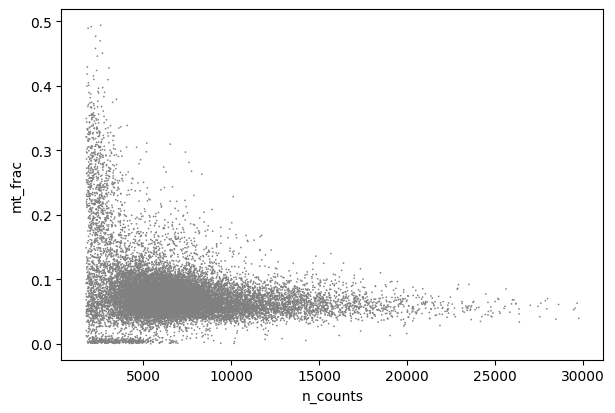

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scanpy\plotting\_utils.py:716: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  color = color[sort]


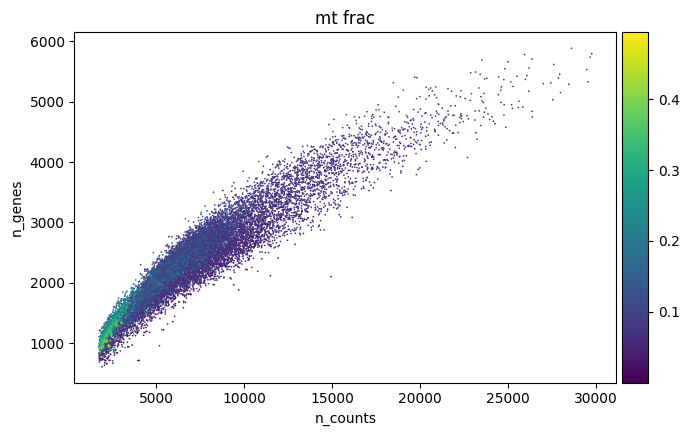

In [69]:
sb.distplot(adata.obs['mt_frac'][adata.obs['mt_frac'] < 0.05], kde=False, bins=60)
plt.show()
sc.pl.scatter(adata, x='n_counts', y='mt_frac')
sc.pl.scatter(adata, x='n_counts', y='n_genes', color='mt_frac')

In [70]:
# Thresholding on number of counts and percent_mito
print('Total number of cells: {:d}'.format(adata.n_obs))
adata = adata[(adata.obs['mt_frac'] > 0.01) | (adata.obs['n_counts'] > 40000)]

print('Number of cells after filter: {:d}'.format(adata.n_obs))

Total number of cells: 20301
Number of cells after filter: 19940


In [71]:
adata.obs['sample'] = '721214'
adata.obs['timepoint'] = 'Diagnosis'
adatas.append(adata)

C:\Users\User\AppData\Local\Temp\ipykernel_10228\4163969107.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['sample'] = '721214'


In [72]:
adata = sc.read('../data/petti/782328.matrix.mtx').T
adata.obs_names = pd.read_csv('../data/petti/782328.barcodes.tsv', delimiter='\t', header=None)[0].values
adata.var_names = pd.read_csv('../data/petti/782328.genes.tsv', delimiter='\t', header=None)[1]
adata

AnnData object with n_obs × n_vars = 21038 × 33694

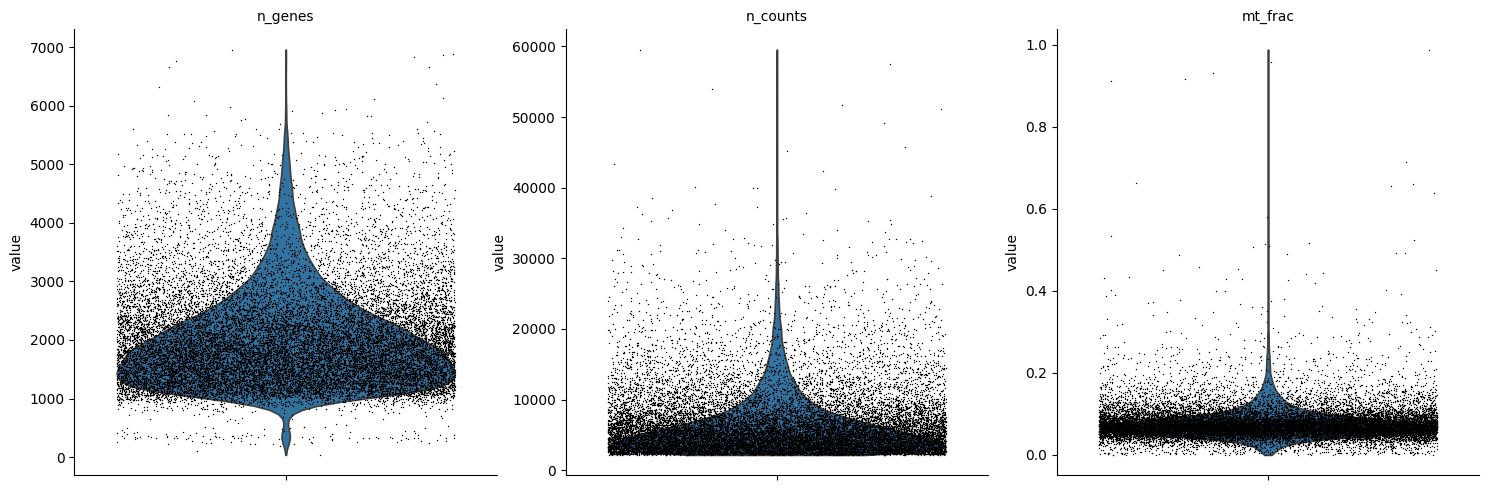

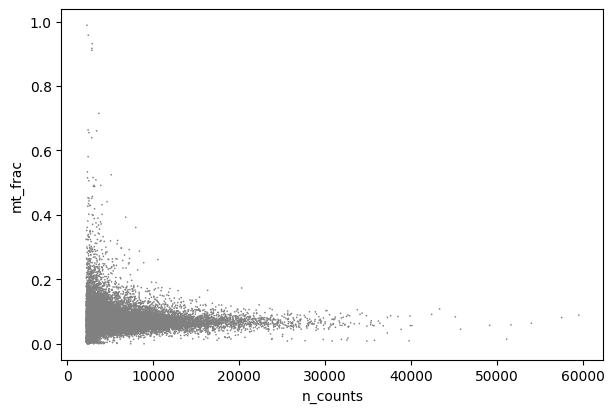

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scanpy\plotting\_utils.py:716: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  color = color[sort]


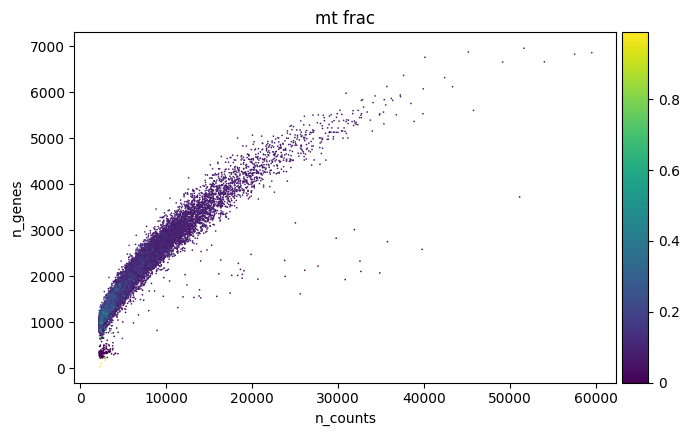

In [73]:
# Quality control - calculate QC covariates
adata.var_names_make_unique()
adata.obs['n_counts'] = adata.X.sum(1)
adata.obs['log_counts'] = np.log(adata.obs['n_counts'])
adata.obs['n_genes'] = (adata.X > 0).sum(1)

adata.X = adata.X.toarray()
mt_gene_mask = [gene.startswith('MT-') for gene in adata.var_names]
adata.obs['mt_frac'] = adata.X[:, mt_gene_mask].sum(1)/adata.obs['n_counts']

# Quality control - plot QC metrics
sc.pl.violin(adata, ['n_genes', 'n_counts', 'mt_frac'],
             jitter=0.4, multi_panel=True)

sc.pl.scatter(adata, x='n_counts', y='mt_frac')
sc.pl.scatter(adata, x='n_counts', y='n_genes', color='mt_frac')

C:\Users\User\AppData\Local\Temp\ipykernel_10228\2253007655.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p3 = sb.distplot(adata.obs['n_counts'], kde=False)


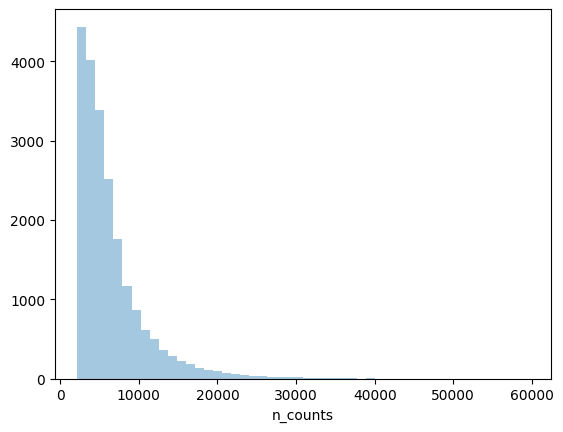

C:\Users\User\AppData\Local\Temp\ipykernel_10228\2253007655.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p4 = sb.distplot(adata.obs['n_counts'][adata.obs['n_counts']<10000], kde=False, bins=60)


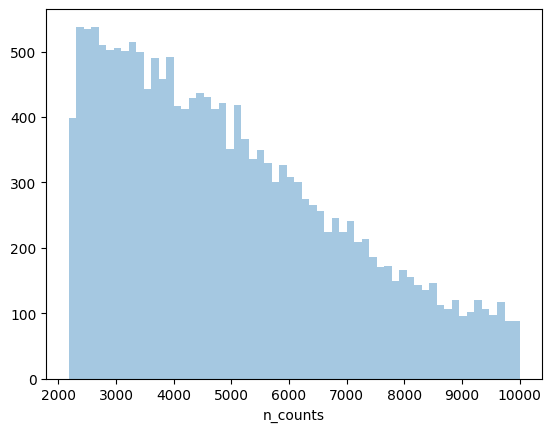

C:\Users\User\AppData\Local\Temp\ipykernel_10228\2253007655.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p5 = sb.distplot(adata.obs['n_counts'][adata.obs['n_counts']>10000], kde=False, bins=60)


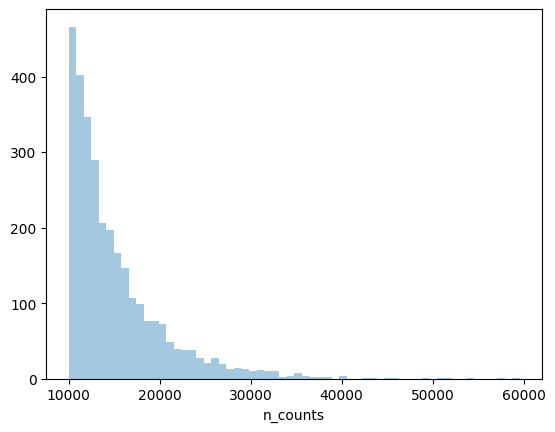

In [74]:
#Thresholding decision: counts
p3 = sb.distplot(adata.obs['n_counts'], kde=False)
plt.show()

p4 = sb.distplot(adata.obs['n_counts'][adata.obs['n_counts']<10000], kde=False, bins=60)
plt.show()

p5 = sb.distplot(adata.obs['n_counts'][adata.obs['n_counts']>10000], kde=False, bins=60)
plt.show()

In [75]:
# Filter cells according to identified QC thresholds:
print('Total number of cells: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, max_counts = 40000)
print('Number of cells after max count filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['mt_frac'] < 0.5]
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Total number of cells: 21038
Number of cells after max count filter: 21027
Number of cells after MT filter: 21010


C:\Users\User\AppData\Local\Temp\ipykernel_10228\710109103.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p6 = sb.distplot(adata.obs['n_genes'], kde=False, bins=60)


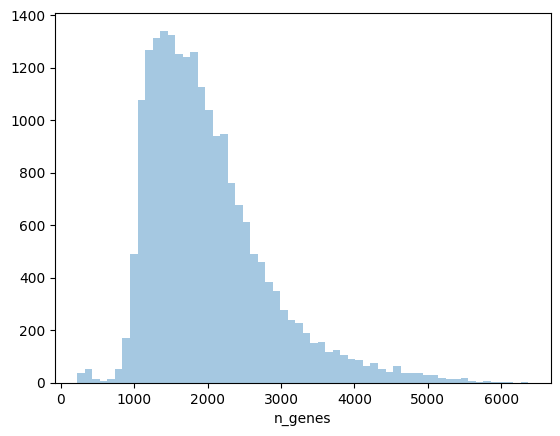

C:\Users\User\AppData\Local\Temp\ipykernel_10228\710109103.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p7 = sb.distplot(adata.obs['n_genes'][adata.obs['n_genes'] < 1000], kde=False, bins=60)


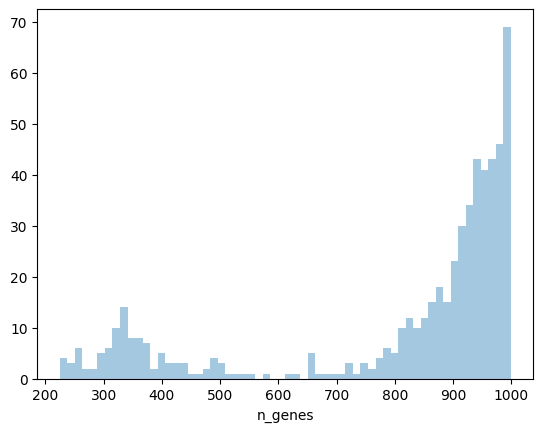

In [76]:
#Thresholding decision: genes
p6 = sb.distplot(adata.obs['n_genes'], kde=False, bins=60)
plt.show()

p7 = sb.distplot(adata.obs['n_genes'][adata.obs['n_genes'] < 1000], kde=False, bins=60)
plt.show()

In [77]:
# Filter cells according to identified QC thresholds:
print('Total number of cells: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes = 600)
print('Number of cells after min genes filter: {:d}'.format(adata.n_obs))

Total number of cells: 21010


C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scanpy\preprocessing\_simple.py:139: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['n_genes'] = number


Number of cells after min genes filter: 20903


C:\Users\User\AppData\Local\Temp\ipykernel_10228\1808565410.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(adata.obs['mt_frac'][adata.obs['mt_frac'] < 0.05], kde=False, bins=60)


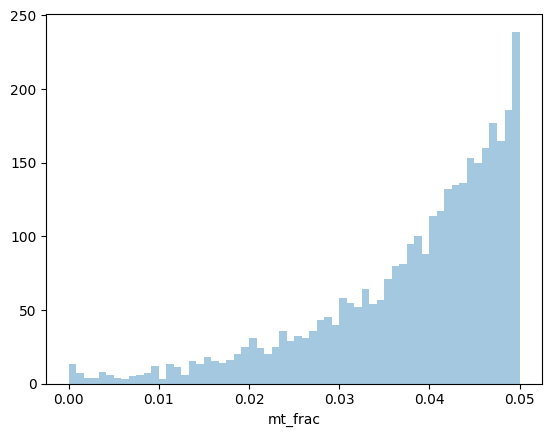

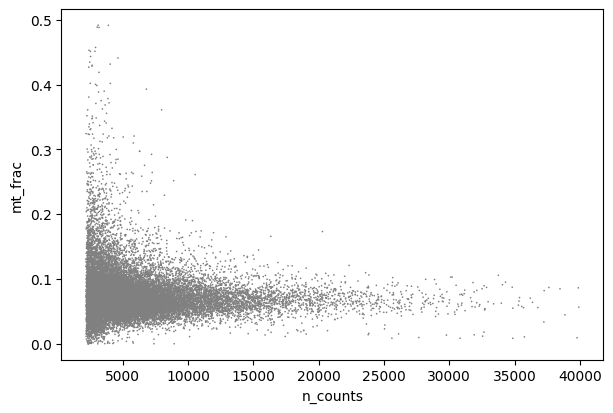

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scanpy\plotting\_utils.py:716: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  color = color[sort]


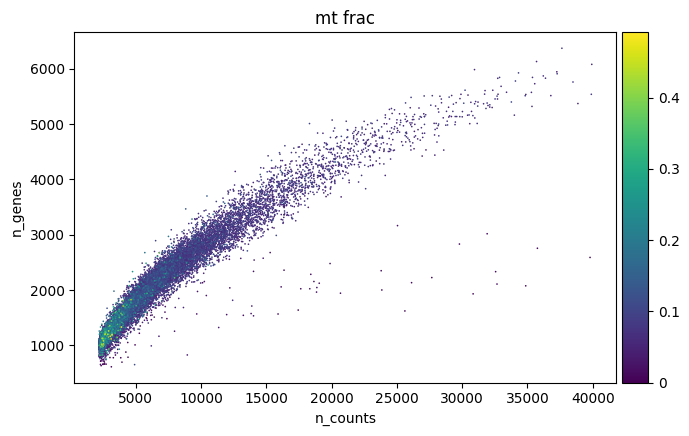

In [78]:
sb.distplot(adata.obs['mt_frac'][adata.obs['mt_frac'] < 0.05], kde=False, bins=60)
plt.show()
sc.pl.scatter(adata, x='n_counts', y='mt_frac')
sc.pl.scatter(adata, x='n_counts', y='n_genes', color='mt_frac')

In [79]:
# Thresholding on number of counts and percent_mito
print('Total number of cells: {:d}'.format(adata.n_obs))
adata = adata[(adata.obs['mt_frac'] > 0.01) | (adata.obs['n_counts'] > 40000)]

print('Number of cells after filter: {:d}'.format(adata.n_obs))

Total number of cells: 20903
Number of cells after filter: 20824


In [80]:
adata.obs['sample'] = '782328'
adata.obs['timepoint'] = 'Diagnosis'
adatas.append(adata)

C:\Users\User\AppData\Local\Temp\ipykernel_10228\3516405638.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['sample'] = '782328'


In [81]:
adata = sc.read('../data/petti/809653.matrix.mtx').T
adata.obs_names = pd.read_csv('../data/petti/809653.barcodes.tsv', delimiter='\t', header=None)[0].values
adata.var_names = pd.read_csv('../data/petti/809653.genes.tsv', delimiter='\t', header=None)[1]
adata

AnnData object with n_obs × n_vars = 21731 × 33694

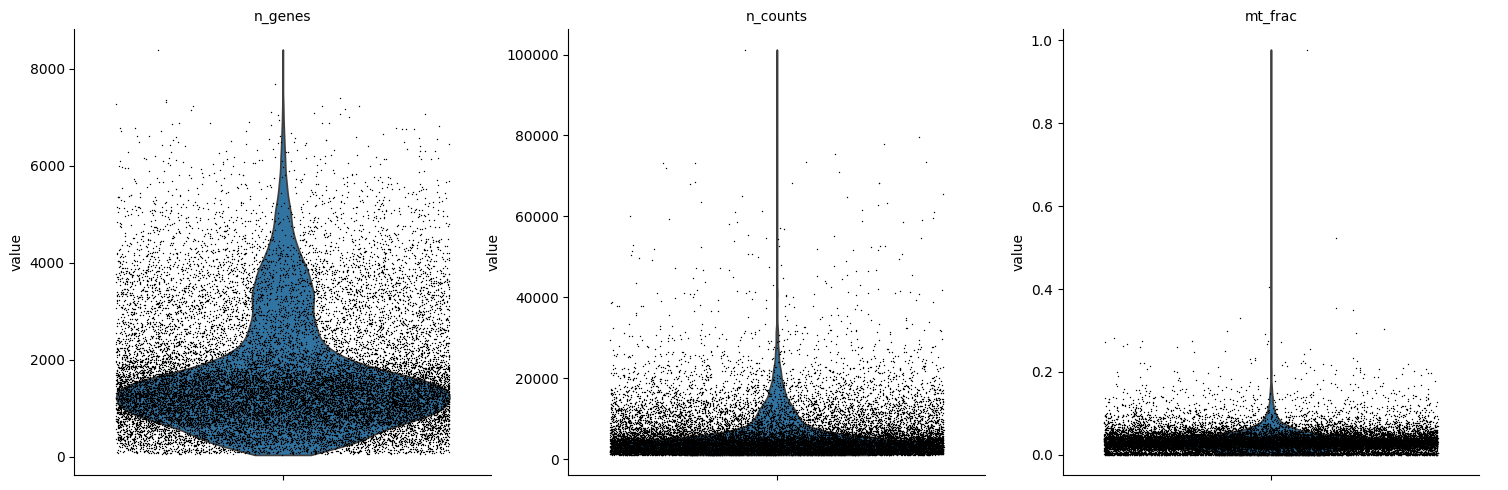

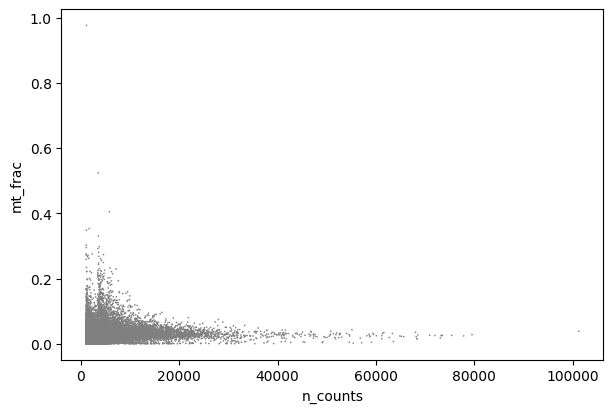

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scanpy\plotting\_utils.py:716: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  color = color[sort]


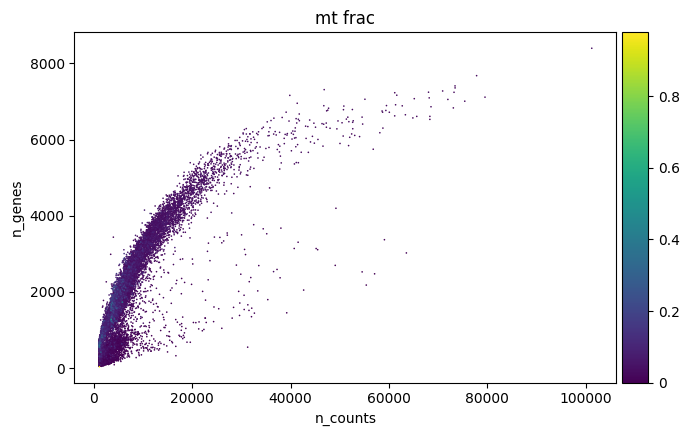

In [82]:
# Quality control - calculate QC covariates
adata.var_names_make_unique()
adata.obs['n_counts'] = adata.X.sum(1)
adata.obs['log_counts'] = np.log(adata.obs['n_counts'])
adata.obs['n_genes'] = (adata.X > 0).sum(1)

adata.X = adata.X.toarray()
mt_gene_mask = [gene.startswith('MT-') for gene in adata.var_names]
adata.obs['mt_frac'] = adata.X[:, mt_gene_mask].sum(1)/adata.obs['n_counts']

# Quality control - plot QC metrics
sc.pl.violin(adata, ['n_genes', 'n_counts', 'mt_frac'],
             jitter=0.4, multi_panel=True)

sc.pl.scatter(adata, x='n_counts', y='mt_frac')
sc.pl.scatter(adata, x='n_counts', y='n_genes', color='mt_frac')

C:\Users\User\AppData\Local\Temp\ipykernel_10228\2253007655.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p3 = sb.distplot(adata.obs['n_counts'], kde=False)


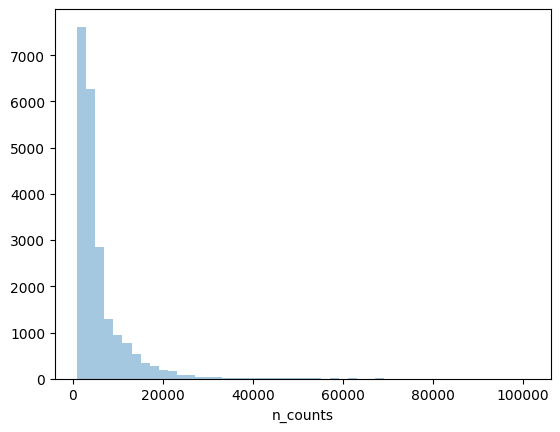

C:\Users\User\AppData\Local\Temp\ipykernel_10228\2253007655.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p4 = sb.distplot(adata.obs['n_counts'][adata.obs['n_counts']<10000], kde=False, bins=60)


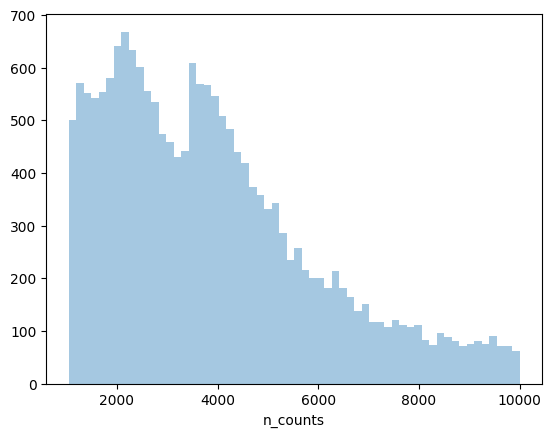

C:\Users\User\AppData\Local\Temp\ipykernel_10228\2253007655.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p5 = sb.distplot(adata.obs['n_counts'][adata.obs['n_counts']>10000], kde=False, bins=60)


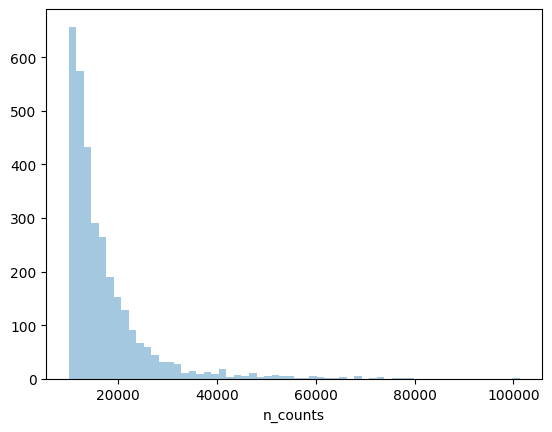

In [83]:
#Thresholding decision: counts
p3 = sb.distplot(adata.obs['n_counts'], kde=False)
plt.show()

p4 = sb.distplot(adata.obs['n_counts'][adata.obs['n_counts']<10000], kde=False, bins=60)
plt.show()

p5 = sb.distplot(adata.obs['n_counts'][adata.obs['n_counts']>10000], kde=False, bins=60)
plt.show()

In [84]:
# Filter cells according to identified QC thresholds:
print('Total number of cells: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, max_counts = 60000)
print('Number of cells after max count filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['mt_frac'] < 0.4]
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Total number of cells: 21731
Number of cells after max count filter: 21705
Number of cells after MT filter: 21702


C:\Users\User\AppData\Local\Temp\ipykernel_10228\4218832875.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p6 = sb.distplot(adata.obs['n_genes'], kde=False, bins=60)


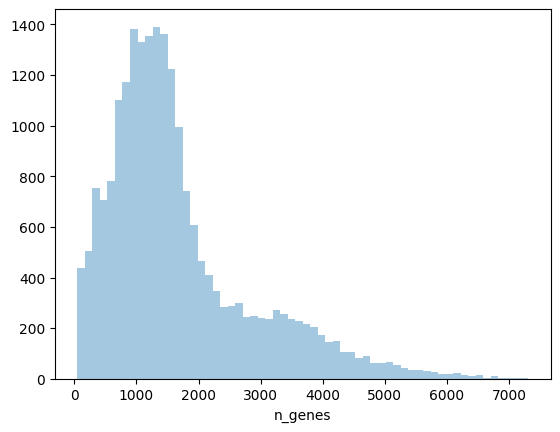

C:\Users\User\AppData\Local\Temp\ipykernel_10228\4218832875.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  p7 = sb.distplot(adata.obs['n_genes'][adata.obs['n_genes'] < 1500], kde=False, bins=60)


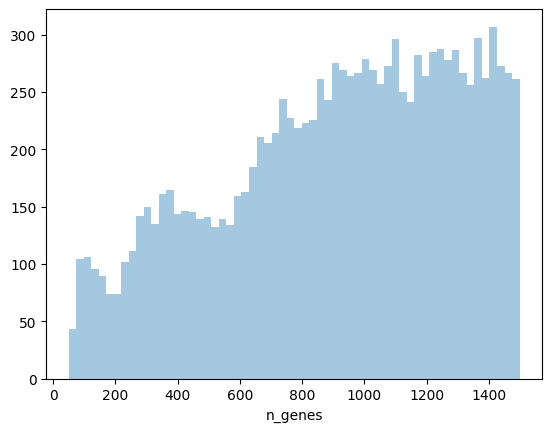

In [85]:
#Thresholding decision: genes
p6 = sb.distplot(adata.obs['n_genes'], kde=False, bins=60)
plt.show()

p7 = sb.distplot(adata.obs['n_genes'][adata.obs['n_genes'] < 1500], kde=False, bins=60)
plt.show()

In [86]:
# Filter cells according to identified QC thresholds:
print('Total number of cells: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes = 600)
print('Number of cells after min genes filter: {:d}'.format(adata.n_obs))

Total number of cells: 21702


C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scanpy\preprocessing\_simple.py:139: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['n_genes'] = number


Number of cells after min genes filter: 18914


C:\Users\User\AppData\Local\Temp\ipykernel_10228\1808565410.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(adata.obs['mt_frac'][adata.obs['mt_frac'] < 0.05], kde=False, bins=60)


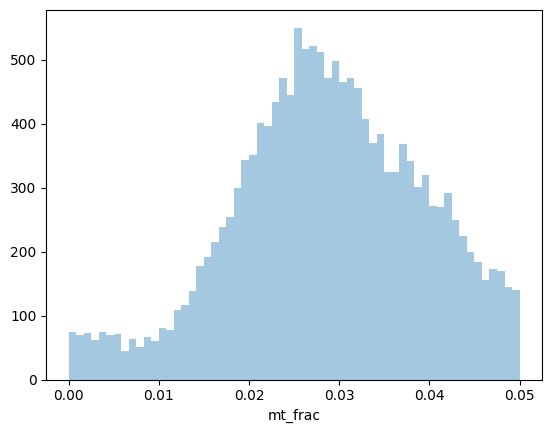

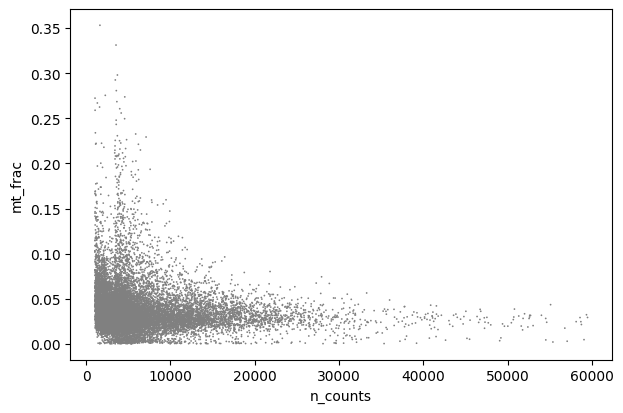

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scanpy\plotting\_utils.py:716: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  color = color[sort]


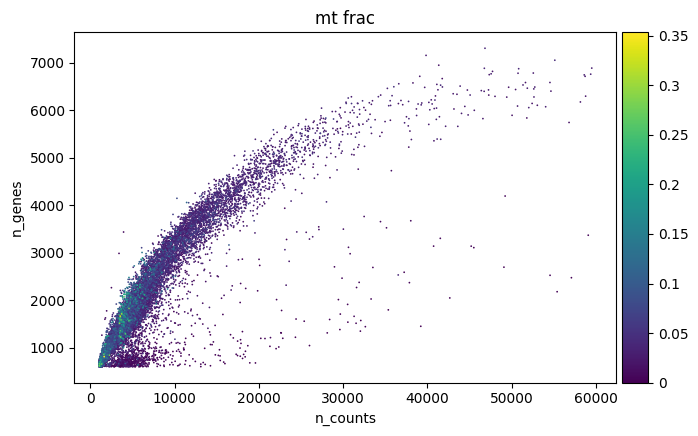

In [87]:
sb.distplot(adata.obs['mt_frac'][adata.obs['mt_frac'] < 0.05], kde=False, bins=60)
plt.show()
sc.pl.scatter(adata, x='n_counts', y='mt_frac')
sc.pl.scatter(adata, x='n_counts', y='n_genes', color='mt_frac')

In [88]:
# Thresholding on number of counts and percent_mito
print('Total number of cells: {:d}'.format(adata.n_obs))
adata = adata[(adata.obs['mt_frac'] > 0.01) | (adata.obs['n_counts'] > 20000)]

print('Number of cells after filter: {:d}'.format(adata.n_obs))

Total number of cells: 18914
Number of cells after filter: 18192


In [89]:
adata.obs['sample'] = '809653'
adata.obs['timepoint'] = 'Diagnosis'
adatas.append(adata)

C:\Users\User\AppData\Local\Temp\ipykernel_10228\2493958977.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['sample'] = '809653'


In [90]:
# merge all samples
samples = ['ND_083017', 'ND_090617', 'Normal_sorted_170531', 'Normal_sorted_170607', '508084', '548327', '721214', '782328', '809653']
adata_merge = adatas[0].concatenate(adatas[1:], batch_key='sample_ID', batch_categories = samples)
adata_merge

C:\Users\User\AppData\Local\Temp\ipykernel_10228\3834819078.py:3: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_merge = adatas[0].concatenate(adatas[1:], batch_key='sample_ID', batch_categories = samples)


AnnData object with n_obs × n_vars = 103612 × 22164
    obs: 'n_counts', 'log_counts', 'n_genes', 'mt_frac', 'sample', 'timepoint', 'sample_ID'

In [91]:
adata_merge.X = sparse.csr_matrix(adata_merge.X).astype(dtype='float32')
adata_merge.layers['counts'] = adata_merge.X
sc.pp.normalize_per_cell(adata_merge, counts_per_cell_after=1e4)
sc.pp.log1p(adata_merge)
adata_merge

AnnData object with n_obs × n_vars = 103612 × 22164
    obs: 'n_counts', 'log_counts', 'n_genes', 'mt_frac', 'sample', 'timepoint', 'sample_ID'
    uns: 'log1p'
    layers: 'counts'

In [92]:
adata_merge.write('../data/petti/petti.h5ad')

----------------------
I used `singleR.R` to predict cell types. Going to see how they look.

In [2]:
adata = sc.read('../../../datasets/petti/petti.h5ad')
labs = pd.read_csv('../../../datasets/petti/petti_cell_labels.csv', sep = '\t')
adata.obs['celltype'] = labs['label']
adata

AnnData object with n_obs × n_vars = 103612 × 22164
    obs: 'n_counts', 'log_counts', 'n_genes', 'mt_frac', 'sample', 'timepoint', 'sample_ID', 'celltype'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'celltype_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'sample_colors', 'timepoint_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scanpy\preprocessing\_highly_variable_genes.py:226: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby("mean_bin")["dispersions"]
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scanpy\plotting\_tools\scatterplots.py:1234:

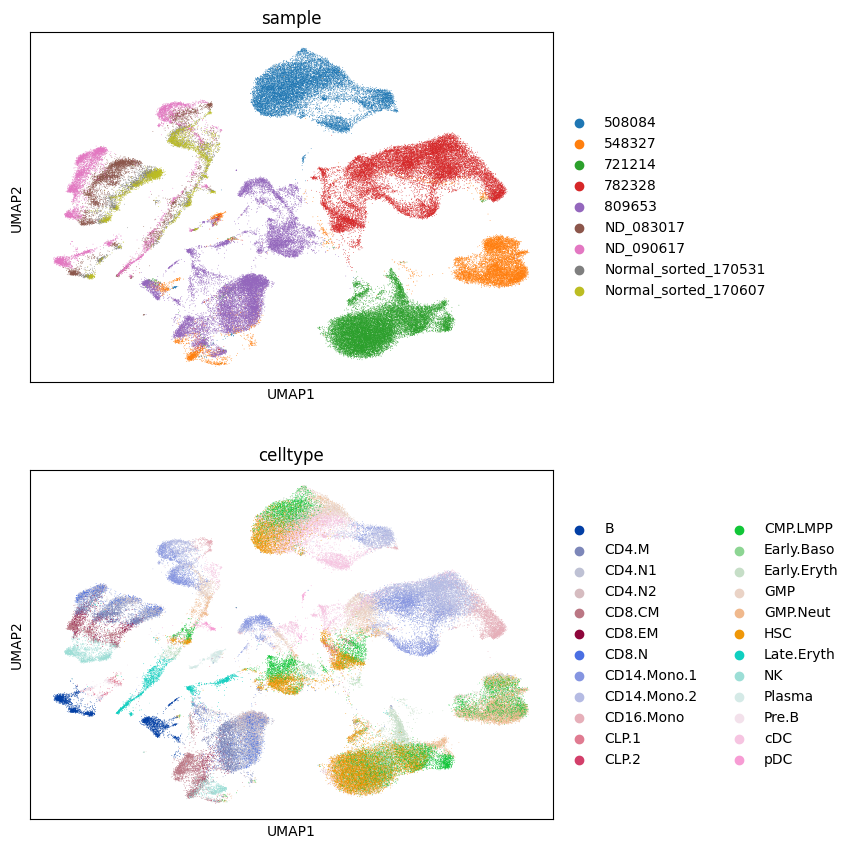

In [3]:
sc.pp.highly_variable_genes(adata, n_top_genes=4000)
sc.pp.pca(adata, n_comps=50, use_highly_variable=True, svd_solver='arpack')
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.pl.umap(adata, color=['sample', 'celltype'], ncols=1)

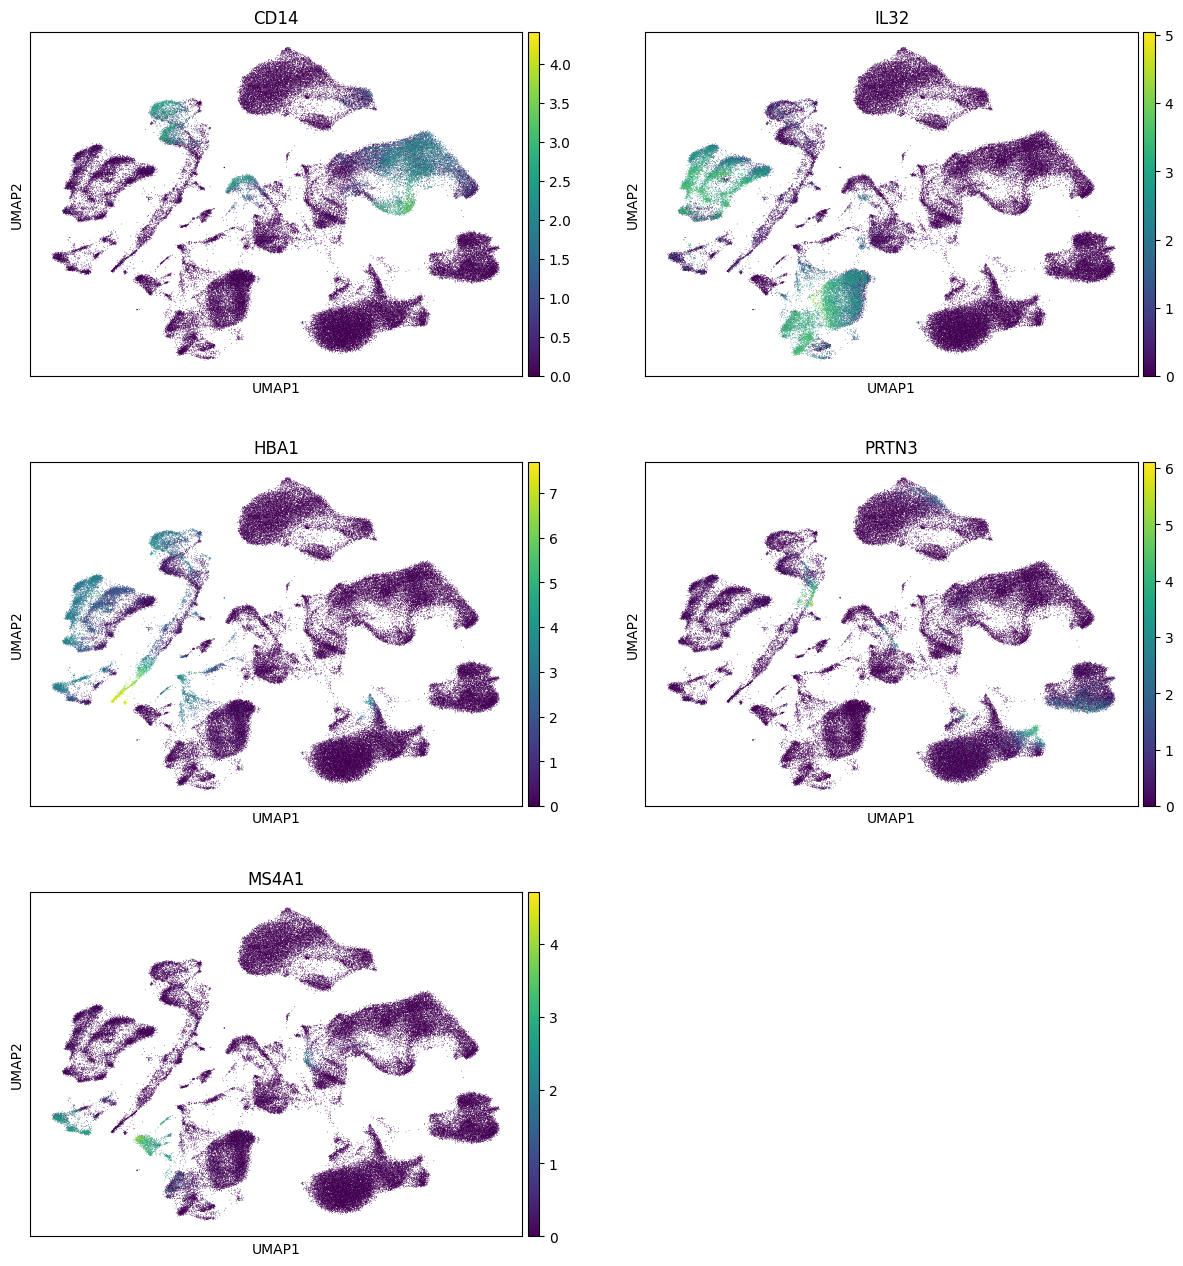

In [4]:
# make sure cells are expressing the genes you'd expect
sc.pl.umap(adata, color=['CD14', 'IL32', 'HBA1', 'PRTN3', 'MS4A1'], ncols=2)

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scanpy\plotting\_tools\scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scanpy\plotting\_tools\scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_ac

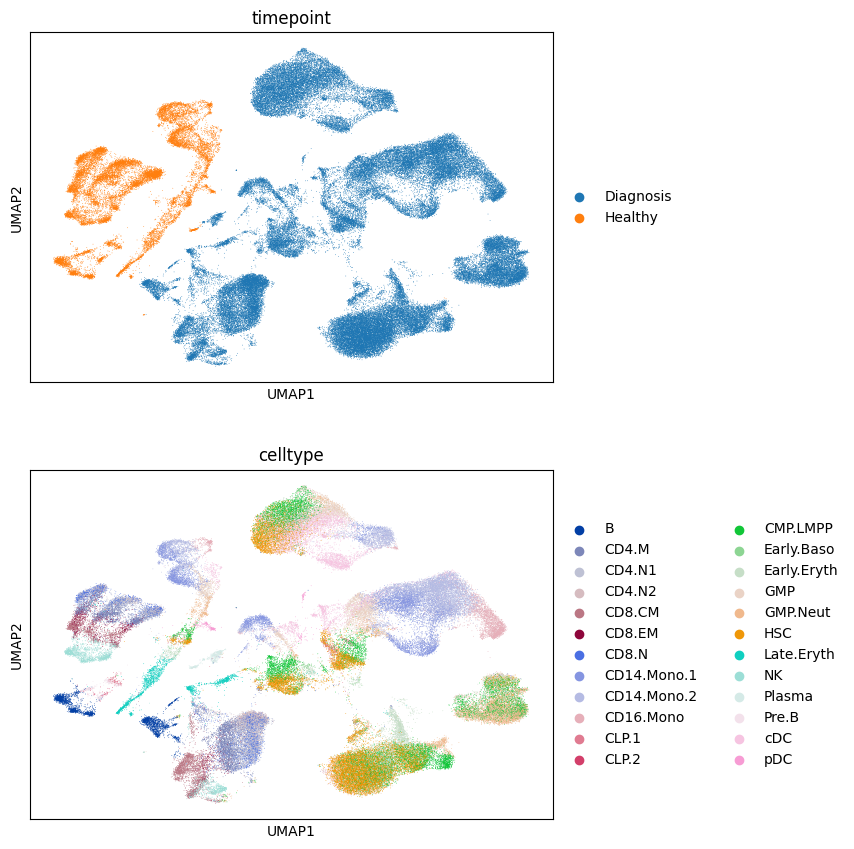

In [5]:
sc.pl.umap(adata, color=['timepoint', 'celltype'], ncols=1)

In [4]:
# save file with cell type labels
adata.write('../../../datasets/petti/petti.h5ad')